# INTELIGENCIA ARTIFICIAL EXPLICATIVA (XAI)

In [1]:
#---- LIBRERIAS PARA LOS DATOS ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#---- LIBRERIAS PARA ML ----
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

#---- LIBRERIAS PARA XAI ----
from lime.lime_tabular import LimeTabularExplainer

#---- LIBRERIAS EXTRAS ----
import os

In [2]:
from ipywidgets import interact, widgets

In [3]:
USER = os.environ["USERNAME"]
directorio_output = F"C:\\Users\\dxcor\\Desktop\\AnteProyecto CI-2025.2026\\Natanael\\licitaciones\\data\\output\\dataEDA"
#directorio_output = "E:\\Repository\\API_Tesis_2025\\API\\model"
archivos = [archivo for archivo in os.listdir(directorio_output) if archivo.endswith(".parquet")]

In [4]:
df = pd.read_parquet(f"{directorio_output}\\{archivos[0]}")

## Funciones

In [5]:
def visualizarImportanciaPredictores(modelo,nombre_modelo:str, experimento:str):
    importancia_predictores = pd.DataFrame({'predictor': df[used_features].columns,'importancia': modelo.feature_importances_})

    # Mostrar la importancia de los predictores ordenada
    print(f"Importancia de los predictores en el modelo {nombre_modelo} - Experimento {experimento}")
    print("-------------------------------------------")
    print(importancia_predictores.sort_values('importancia', ascending=False))

In [6]:
def generarGraficoMatrizConfusion(matriz,clases):
    # Configurar el tamaño del gráfico
    plt.figure(figsize=(25, 13))

    # Crear la matriz de confusión con seaborn
    sns.heatmap(matriz, annot=True, cmap='Blues', fmt='g', xticklabels=clases, yticklabels=clases, 
                linewidths=.5,square=True,annot_kws={"size": 10}, linecolor="blue")

    # Configurar etiquetas y título
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [7]:
def generarComparativaModelos(prediccion_random_forest, prediccion_gradient_boosting, y_test):
    models = {
    'Random Forest': prediccion_random_forest,
    'Gradient Boosting': prediccion_gradient_boosting
    }

    metrics = ['accuracy', 'precision', 'recall', 'f1']

    # Crear un diccionario para almacenar los resultados
    results = {}

    for model_name, y_pred in models.items():
        results[model_name] = {
            'accuracy': accuracy_score(y_test.values, y_pred),
            'precision': precision_score(y_test.values, y_pred, average='macro'),
            'recall': recall_score(y_test.values, y_pred, average='macro'),
            'f1': f1_score(y_test.values, y_pred, average='macro')
        }

    # Imprimir los resultados de manera más compacta
    print("METRICAS               ACCURACY  PRECISION  RECALL  F1")
    for model_name, metrics_dict in results.items():
        print(f"{model_name:<20} -> {metrics_dict['accuracy']:.4f}    {metrics_dict['precision']:.4f}   {metrics_dict['recall']:.4f}   {metrics_dict['f1']:.4f}")

In [8]:
def generarGraficosExplicativos(df: pd.DataFrame, clases, modelo, prediccion):
    explainer = LimeTabularExplainer(training_data=df.values,
                                    feature_names= df.columns,
                                    class_names=clases,
                                    mode='classification')
    
    for i in range(len(df.values)):
        exp = explainer.explain_instance(
            df.values[i],
            predict_fn=modelo.predict_proba,
            num_features=len(df.columns)
        )

        # Obtener las etiquetas disponibles
        available_labels = exp.available_labels()
        
        # Obtener reglas para todas las clases disponibles
        for class_name in available_labels:
            print(f"Reglas para la clase {class_name}:")
            rules = convert_to_if_then(exp, class_name, prediccion[i])
            for rule in rules:
                print(f"  {rule}")
        
        # Mostrar las explicaciones en el notebook (opcional)
        exp.show_in_notebook(show_table=True, show_all=False)

In [9]:
def calculate_class_metrics(confusion_matrix, class_names):
    num_classes = confusion_matrix.shape[0]
    metrics = {}

    for i in range(num_classes):
        tp = confusion_matrix[i, i]
        fn = np.sum(confusion_matrix[i, :]) - tp
        fp = np.sum(confusion_matrix[:, i]) - tp
        tn = np.sum(confusion_matrix) - (tp + fp + fn)

        metrics[class_names[i]] = {
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn
        }
    
    return metrics

In [10]:
def generarGraficoMetricas(clase_name, metrics):
    def update_plot(clase_name):
        # Obtener los valores para la clase seleccionada
        valores = metrics[clase_name]
        
        categories = ['TP', 'TN', 'FP', 'FN']
        values = [valores['TP'], valores['TN'], valores['FP'], valores['FN']]
        
        # Crear el gráfico
        plt.figure(figsize=(8, 4))
        bars = plt.bar(categories, values, color=['blue', 'green', 'red', 'orange'])
        #plt.title(f'Métricas para {clase_name}')
        plt.ylabel('Número de Instancias')
        plt.xlabel(f"Metricas para {clase_name}")
        plt.ylim(0, max(values) + 10)  # Ajustar el límite superior del eje y para mejor visualización
        
        # Añadir etiquetas sobre cada barra
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, int(yval), ha='center', va='bottom')
    
        plt.show()

    # Crear un widget Dropdown para seleccionar la clase
    dropdown = widgets.Dropdown(
        options=clase_name,
        value=clase_name[0],  # Valor inicial
        description='Clase:',
        disabled=False
    )

    # Crear la interfaz interactiva
    interact(update_plot, clase_name=dropdown)

## Selección de N mejores caracteristicas según la correlación

In [11]:
# --- Corrección del nombre de columna en el DataFrame original ---
df.rename(columns={
    "MAIN_ACTIVITY_general public\\services": "MAIN_ACTIVITY_general_public_services"
}, inplace=True)

# --- Lista corregida de características usadas ---
used_features = [
    "B_MULTIPLE_CAE_n", "B_ON_BEHALF_n",
    "GROUP_CPV_45", "GROUP_CPV_33", "GROUP_CPV_15",
    "TYPE_OF_CONTRACT_w", "MAIN_ACTIVITY_health", "ISO_COUNTRY_CODE_si",
    "NUMBER_AWARDS", "LOTS_NUMBER", 
    "NUMBER_OFFERS", "NUMBER_TENDERS_SME",
    "CAE_TYPE_3", "MAIN_ACTIVITY_general_public_services",
    "CAE_TYPE_4", "CAE_TYPE_5", "ISO_COUNTRY_CODE_lu"
]


## Variables

In [12]:
etiquetas_a_clasificar = df[[c for c in df.columns if c not in used_features]].drop(columns=
    ["CAE_NAME", "CAE_TOWN", "DURATION", "VALUE_EURO", "CPV", 'CRIT_CRITERIA', 
    'CRIT_WEIGHTS', 'CRIT_PRICE_WEIGHT']
    ).columns

In [13]:
etiquetas_a_clasificar

Index(['WIN_COUNTRY_CODE', 'B_CONTRACTOR_SME', 'GROUP_CPV', 'GROUP_VALUE_EURO',
       'GROUP_DURATION', 'YEAR', 'CAE_TYPE', 'B_MULTIPLE_CAE', 'CAE_GPA_ANNEX',
       'B_ON_BEHALF', 'ID_TYPE', 'ISO_COUNTRY_CODE', 'TOP_TYPE',
       'TYPE_OF_CONTRACT', 'B_SUBCONTRACTED', 'MAIN_ACTIVITY'],
      dtype='object')

## Datos de entrenamiento y de prueba

In [14]:
X: pd.DataFrame = df.drop(columns=["MAIN_ACTIVITY", "GROUP_DURATION"], axis=1)        # Caracteristicas 
Y_GA = df["MAIN_ACTIVITY"]   
Y_GB = df["GROUP_DURATION"]                                          # Objetivo

In [15]:
# Dividir el DataFrame en conjuntos de entrenamiento y prueba (70-15-15)
# Donde 70% para entrenamiento - 15% para pruba - 15% para evaluación.

In [16]:
X_train_GA, X_temp_GA, y_train_GA, y_temp_GA = train_test_split(X, Y_GA, test_size=0.3, random_state=42)  # 30% para prueba-validación
X_test_GA, X_vali_GA, y_test_GA, y_vali_GA = train_test_split(X_temp_GA, y_temp_GA, test_size=0.5, random_state=42)  # 50% de 30% para prueba (15%) y valiuación (15%)

In [17]:
X_train_GB, X_temp_GB, y_train_GB, y_temp_GB = train_test_split(X, Y_GB, test_size=0.3, random_state=42)  # 30% para prueba-validación
X_test_GB, X_vali_GB, y_test_GB, y_vali_GB = train_test_split(X_temp_GB, y_temp_GB, test_size=0.5, random_state=42)  # 50% de 30% para prueba (15%) y evaluación (15%)

In [18]:
classes_GA = y_test_GA.sort_values().unique()
classes_GB = y_test_GB.sort_values().unique()

In [19]:
del X, Y_GA, Y_GB

## Modelos

### Validación Cruzada

In [20]:
random_forest_model = RandomForestClassifier(
    bootstrap=True,
    n_jobs=-1,
    max_samples=2/3,
    random_state=42, 
    n_estimators=100,
    warm_start=False)

In [21]:
parametros_a_explorar = {
    "criterion": ["gini", "entropy"], 
    "max_features": ["sqrt","log2"]}

In [22]:
parametros_a_explorar_GB = {"max_features": ['sqrt', 'log2']}

### EXPERIMENTO A

In [ ]:
X_combined = np.vstack((X_train_GA[used_features], X_vali_GA[used_features]))
y_combined = np.concatenate((y_train_GA, y_vali_GA))

In [ ]:
test_fold = np.full(X_combined.shape[0], -1)  # Inicialmente, todas las muestras están en el conjunto de entrenamiento
test_fold[len(X_train_GA[used_features]):(len(X_train_GA[used_features]) + len(X_vali_GA[used_features]))] = 0  # Las muestras del conjunto de prueba están en el conjunto de validación

In [ ]:
ps = PredefinedSplit(test_fold=test_fold)

In [26]:
rejilla_GA = RandomizedSearchCV(estimator=random_forest_model, 
                      param_distributions=parametros_a_explorar, 
                      scoring='accuracy',
                      n_jobs=-1, 
                      random_state=42,
                      cv=ps)
rejilla_GA.fit(X_combined, y_combined)

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2']}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,"PredefinedSpl...pe=(419679,)))"
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [27]:
print(f"El mejor accuracy es de {rejilla_GA.best_score_} lo tienen los HiperParametros {rejilla_GA.best_params_}")

El mejor accuracy es de 0.8345823037766166 lo tienen los HiperParametros {'max_features': 'sqrt', 'criterion': 'gini'}


#### Entrenamiento

In [28]:
random_forest_model_GA = rejilla_GA.best_estimator_

In [29]:
gb_model_GA = GradientBoostingClassifier(
    learning_rate=0.1,     
    init=random_forest_model_GA        # Establecer el random_forest_model pre-entrenado como el estimador base
)

#### Random Forest

In [30]:
y_rf_pred_GA = random_forest_model_GA.predict(X_test_GA[used_features])

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


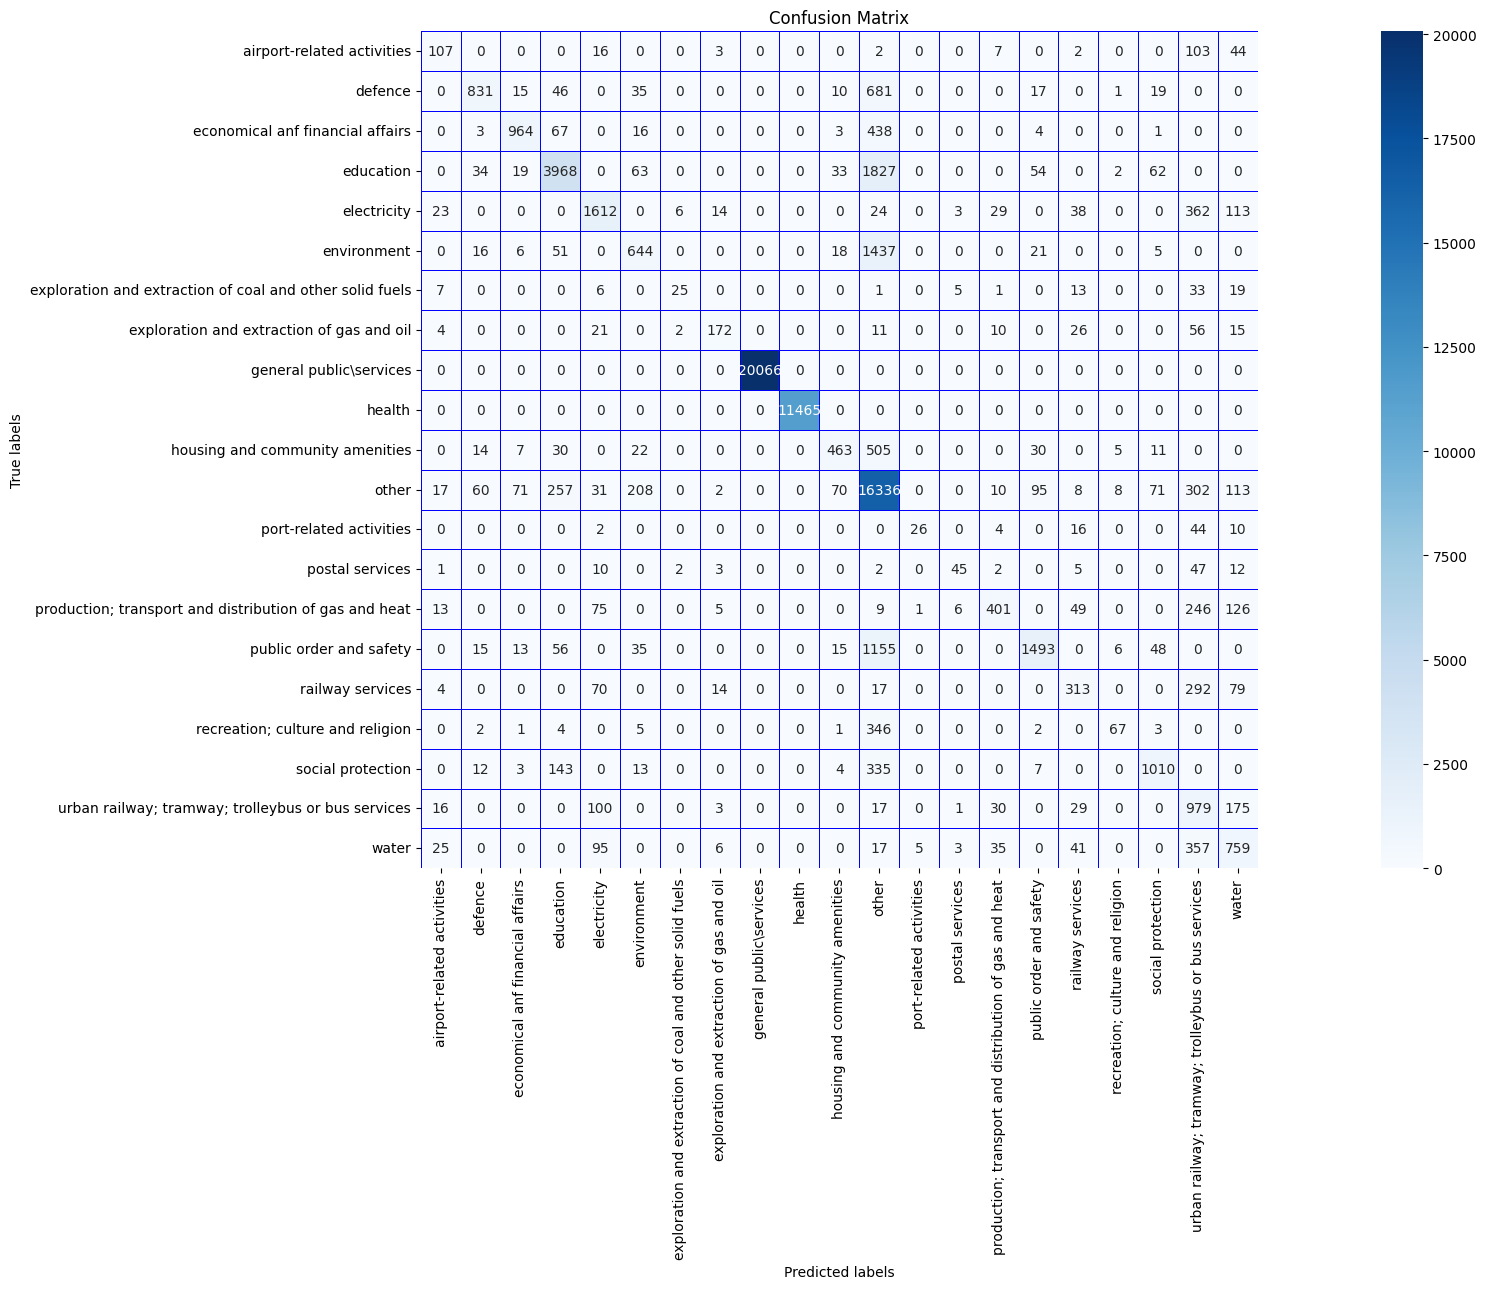

In [31]:
cnf_matrix_RF_GA=confusion_matrix(y_test_GA, y_rf_pred_GA)
generarGraficoMatrizConfusion(cnf_matrix_RF_GA, classes_GA)

In [32]:
metrics = calculate_class_metrics(cnf_matrix_RF_GA, classes_GA)
generarGraficoMetricas(classes_GA, metrics)

interactive(children=(Dropdown(description='Clase:', options=('airport-related activities', 'defence', 'econom…

In [33]:
visualizarImportanciaPredictores(random_forest_model_GA, "RANDOM FOREST", "A")

Importancia de los predictores en el modelo RANDOM FOREST - Experimento A
-------------------------------------------
                                predictor  importancia
13  MAIN_ACTIVITY_general_public_services     0.321547
6                    MAIN_ACTIVITY_health     0.163550
8                           NUMBER_AWARDS     0.096012
9                             LOTS_NUMBER     0.086634
3                            GROUP_CPV_33     0.070151
10                          NUMBER_OFFERS     0.058054
14                             CAE_TYPE_4     0.052990
11                     NUMBER_TENDERS_SME     0.048584
12                             CAE_TYPE_3     0.033222
15                             CAE_TYPE_5     0.014599
4                            GROUP_CPV_15     0.014559
1                           B_ON_BEHALF_n     0.009952
7                     ISO_COUNTRY_CODE_si     0.009129
16                    ISO_COUNTRY_CODE_lu     0.007542
0                        B_MULTIPLE_CAE_n     0.005365
5 

#### Gradient Boosting con Random Forest

In [34]:
random_search_gb = RandomizedSearchCV(estimator=gb_model_GA, 
                                    param_distributions=parametros_a_explorar_GB,
                                    scoring='accuracy',
                                    n_jobs=-1, 
                                    random_state=42, 
                                    cv=ps)
random_search_gb.fit(X_combined, y_combined)

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
print(f"El mejor accuracy es de {random_search_gb.best_score_} lo tiene los HiperParametros {random_search_gb.best_params_}")

El mejor accuracy es de 0.8345417966271047 lo tiene los HiperParametros {'max_features': 'sqrt'}


In [ ]:
gb_model_GA = random_search_gb.best_estimator_

In [ ]:
y_pred_gb_GA = gb_model_GA.predict(X_test_GA[used_features])

c:\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


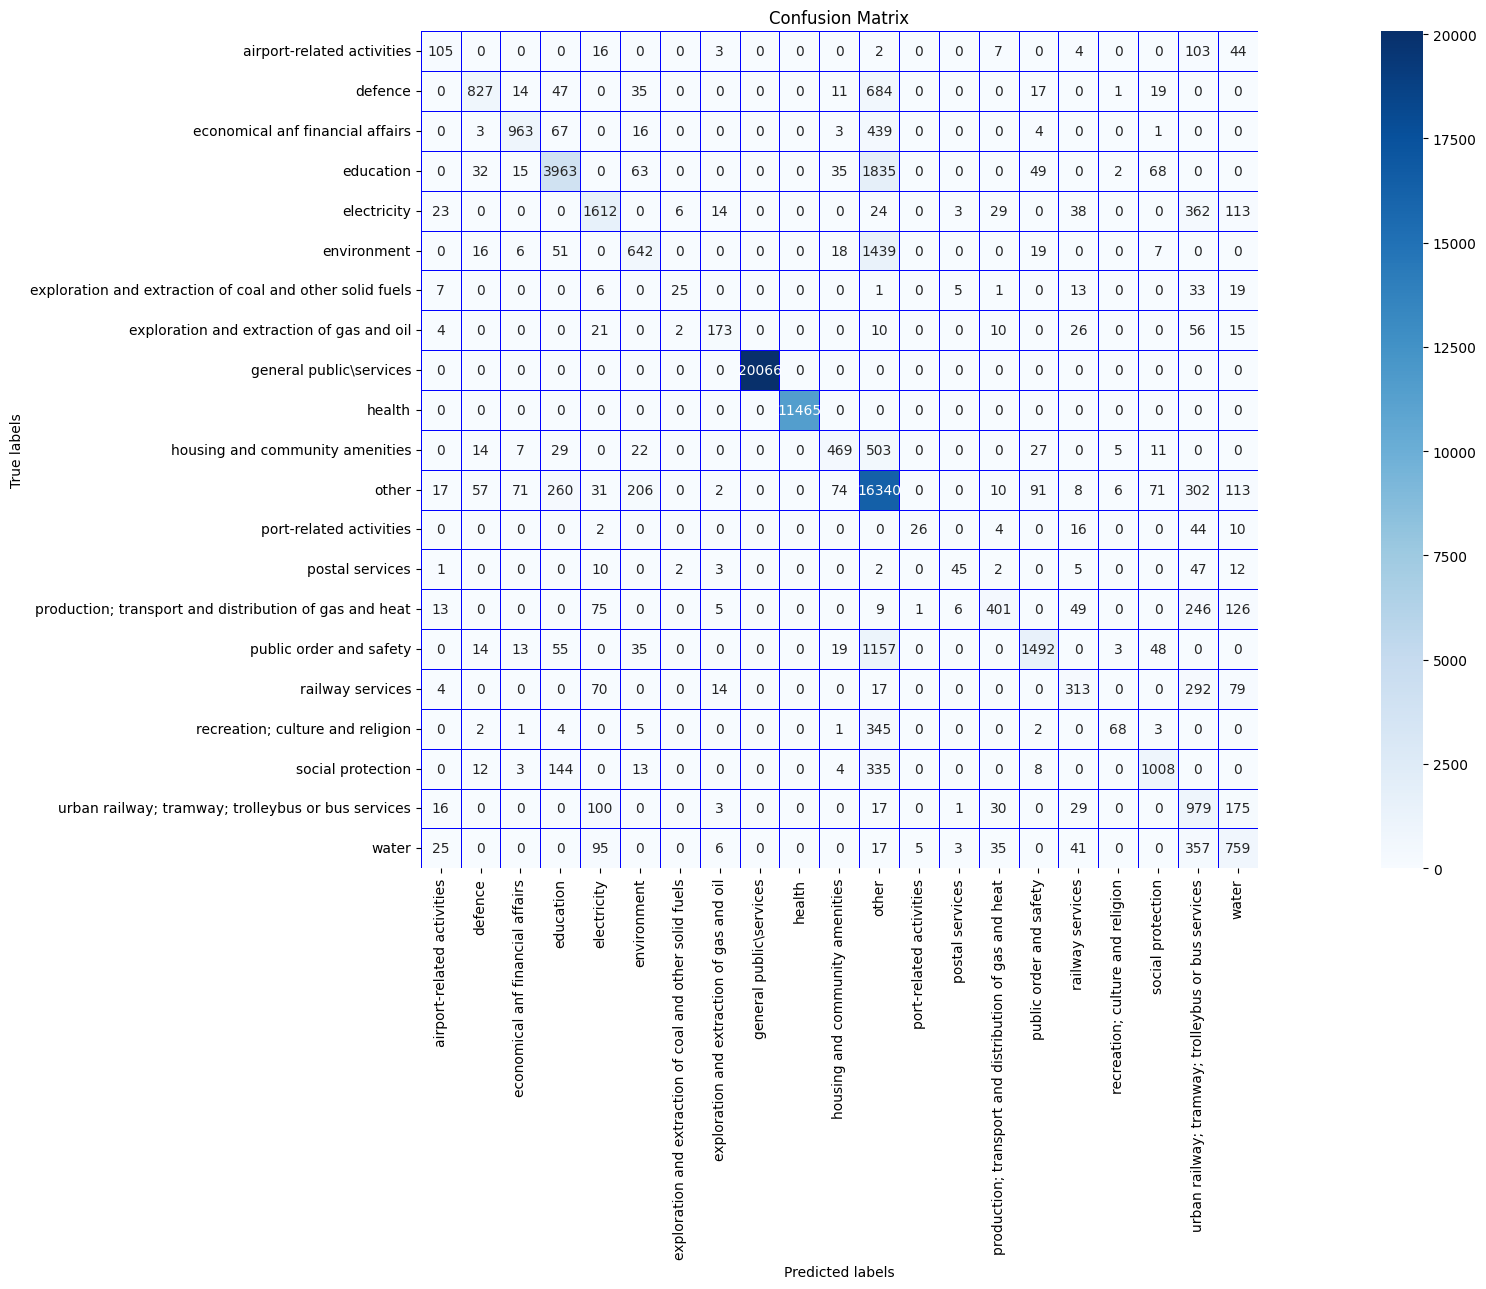

In [ ]:
cnf_matrix_GB_GA = confusion_matrix(y_test_GA, y_pred_gb_GA)
generarGraficoMatrizConfusion(cnf_matrix_GB_GA, classes_GA)

In [ ]:
metrics = calculate_class_metrics(cnf_matrix_GB_GA, classes_GA)
generarGraficoMetricas(classes_GA, metrics)

In [ ]:
visualizarImportanciaPredictores(gb_model_GA, "GRADIENT BOOSTING", "A")

Importancia de los predictores en el modelo GRADIENT BOOSTING - Experimento A
-------------------------------------------
                                predictor  importancia
9                             LOTS_NUMBER     0.245214
8                           NUMBER_AWARDS     0.215469
11                     NUMBER_TENDERS_SME     0.152201
10                          NUMBER_OFFERS     0.137373
4                            GROUP_CPV_15     0.050781
1                           B_ON_BEHALF_n     0.040915
5                      TYPE_OF_CONTRACT_w     0.026261
7                     ISO_COUNTRY_CODE_si     0.025078
0                        B_MULTIPLE_CAE_n     0.024908
13  MAIN_ACTIVITY_general public\services     0.018176
12                             CAE_TYPE_3     0.017911
2                            GROUP_CPV_45     0.016991
3                            GROUP_CPV_33     0.010685
14                             CAE_TYPE_4     0.009884
6                    MAIN_ACTIVITY_health     0.00585

### EXPERIMENTO B

In [35]:
X_combined_GB = np.vstack((X_train_GB[used_features], X_vali_GB[used_features]))
y_combined_GB = np.concatenate((y_train_GB,y_vali_GB))

In [36]:
test_fold_GB = np.full(X_combined_GB.shape[0], -1)  # Inicialmente, todas las muestras están en el conjunto de entrenamiento
test_fold_GB[len(X_train_GB[used_features]):(len(X_train_GB[used_features]) + len(X_vali_GB[used_features]))] = 0  # Las muestras del conjunto de prueba están en el conjunto de validación

In [37]:
ps_GB = PredefinedSplit(test_fold=test_fold_GB)

In [38]:
rejilla_GB = RandomizedSearchCV(estimator=random_forest_model, 
                      param_distributions=parametros_a_explorar, 
                      scoring='accuracy', 
                      n_jobs=-1,
                      cv=ps_GB)
rejilla_GB.fit(X_combined_GB, y_combined_GB)

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2']}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,"PredefinedSpl...pe=(419679,)))"
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [39]:
print(f"El mejor accuracy es de {rejilla_GB.best_score_} lo tiene los HiperParametros {rejilla_GB.best_params_}")

El mejor accuracy es de 0.9899002173883691 lo tiene los HiperParametros {'max_features': 'sqrt', 'criterion': 'entropy'}


#### Entrenamiento

In [40]:
random_forest_model_GB = rejilla_GB.best_estimator_

In [41]:
gb_model_GB = GradientBoostingClassifier(
    learning_rate=0.1,          
    init=random_forest_model_GB        # Establecer el random_forest_model pre-entrenado como el estimador base
)

#### Random Forest

In [42]:
y_rf_pred_GB = random_forest_model_GB.predict(X_test_GB[used_features])

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


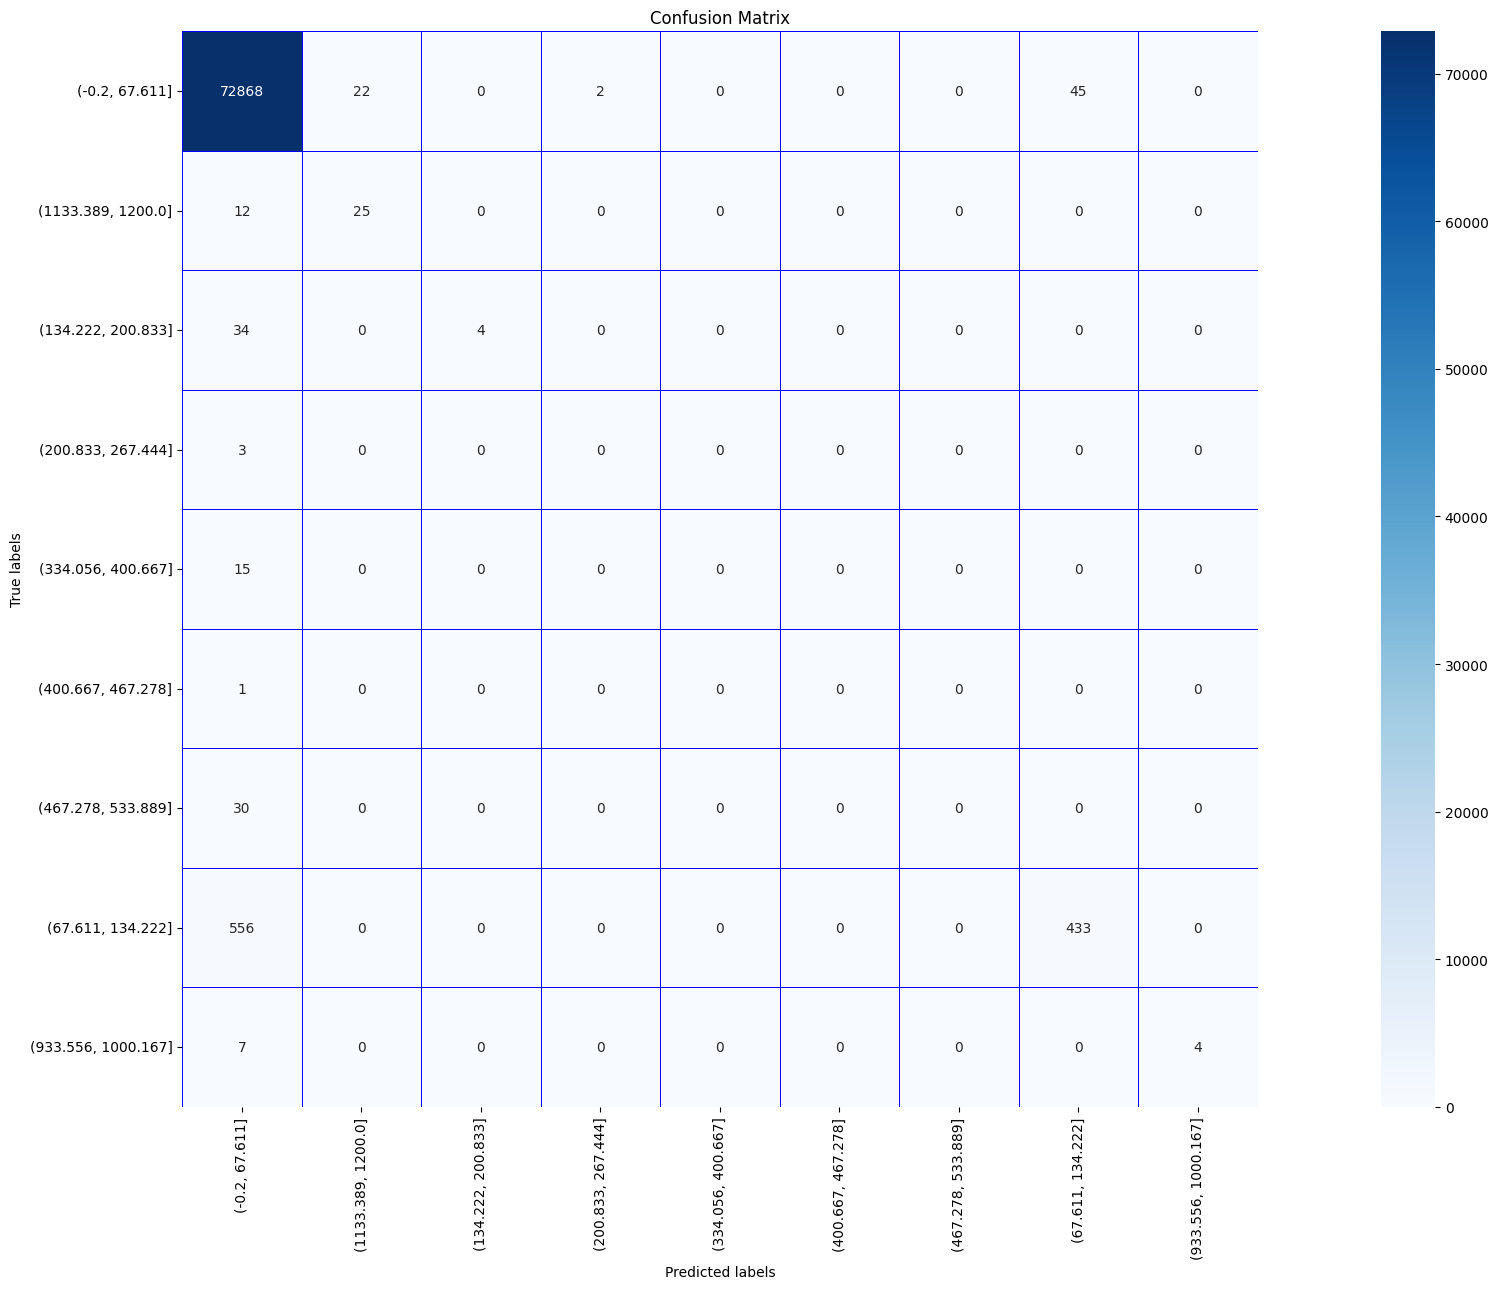

In [43]:
cnf_matrix_RF_GB=confusion_matrix(y_test_GB, y_rf_pred_GB)
generarGraficoMatrizConfusion(cnf_matrix_RF_GB, classes_GB)

In [44]:
metrics = calculate_class_metrics(cnf_matrix_RF_GB, classes_GB)
generarGraficoMetricas(classes_GB, metrics)

interactive(children=(Dropdown(description='Clase:', options=('(-0.2, 67.611]', '(1133.389, 1200.0]', '(134.22…

In [45]:
visualizarImportanciaPredictores(random_forest_model_GB, "RANDOM FOREST", "B")

Importancia de los predictores en el modelo RANDOM FOREST - Experimento B
-------------------------------------------
                                predictor  importancia
8                           NUMBER_AWARDS     0.223706
9                             LOTS_NUMBER     0.197382
10                          NUMBER_OFFERS     0.134636
11                     NUMBER_TENDERS_SME     0.113017
15                             CAE_TYPE_5     0.045162
13  MAIN_ACTIVITY_general_public_services     0.043592
14                             CAE_TYPE_4     0.042516
1                           B_ON_BEHALF_n     0.038911
5                      TYPE_OF_CONTRACT_w     0.025973
6                    MAIN_ACTIVITY_health     0.024853
2                            GROUP_CPV_45     0.023748
3                            GROUP_CPV_33     0.023014
12                             CAE_TYPE_3     0.021146
0                        B_MULTIPLE_CAE_n     0.015455
16                    ISO_COUNTRY_CODE_lu     0.012956
4 

#### Gradient Boosting

In [46]:
random_search_EB_gb = RandomizedSearchCV(estimator=gb_model_GB, 
                                    param_distributions=parametros_a_explorar_GB,
                                    scoring='accuracy',
                                    n_jobs=-1, 
                                    random_state=42, 
                                    cv=ps_GB)
random_search_EB_gb.fit(X_combined_GB, y_combined_GB)

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,GradientBoost...dom_state=42))
,param_distributions,"{'max_features': ['sqrt', 'log2']}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,"PredefinedSpl...pe=(419679,)))"
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [47]:
print(f"El mejor accuracy es de {random_search_EB_gb.best_score_} lo tiene los HiperParametros {random_search_EB_gb.best_params_}")

El mejor accuracy es de 0.9899137197715396 lo tiene los HiperParametros {'max_features': 'log2'}


In [48]:
gb_model_GB = random_search_EB_gb.best_estimator_

In [49]:
y_pred_gb_GB = gb_model_GB.predict(X_test_GB[used_features])

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


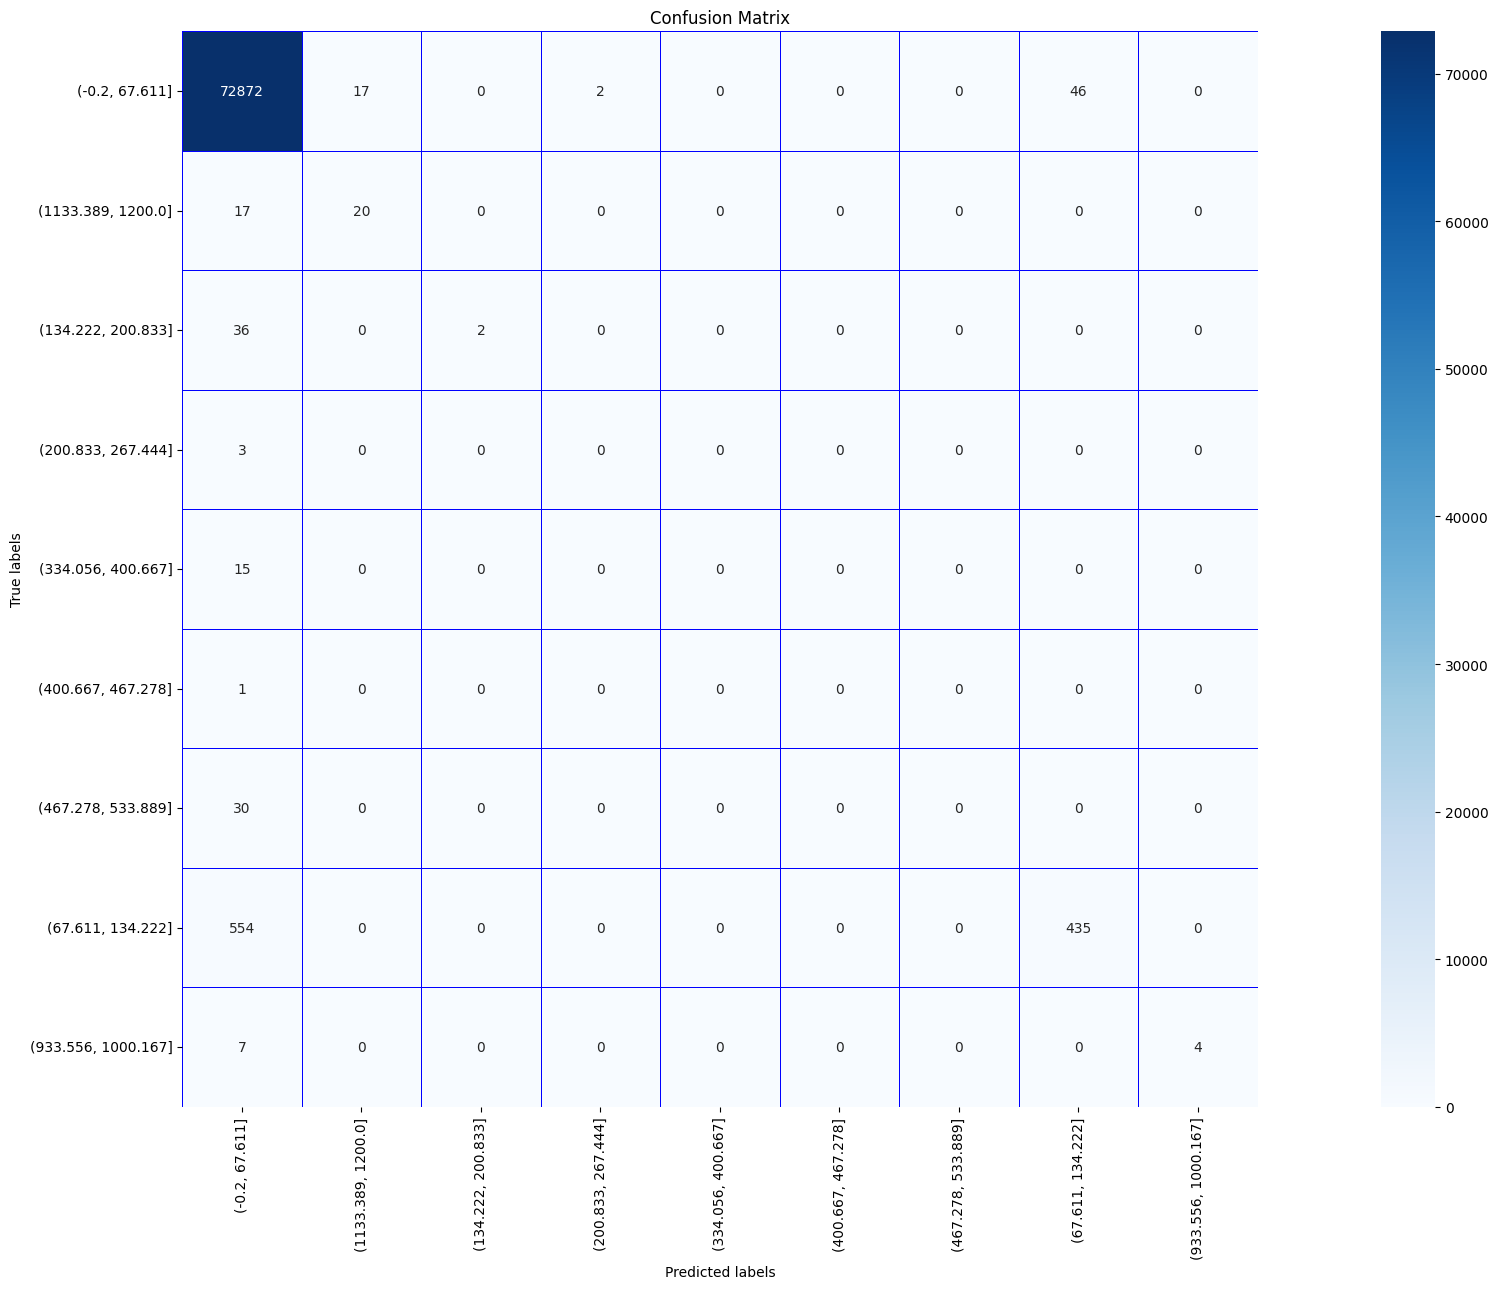

In [50]:
cnf_matrix_GB_GB = confusion_matrix(y_test_GB, y_pred_gb_GB)
generarGraficoMatrizConfusion(cnf_matrix_GB_GB, classes_GB)

In [51]:
metrics = calculate_class_metrics(cnf_matrix_GB_GB, classes_GB)
generarGraficoMetricas(classes_GB, metrics)

interactive(children=(Dropdown(description='Clase:', options=('(-0.2, 67.611]', '(1133.389, 1200.0]', '(134.22…

In [52]:
visualizarImportanciaPredictores(gb_model_GB, "GRADIENT BOOSTING", "B")

Importancia de los predictores en el modelo GRADIENT BOOSTING - Experimento B
-------------------------------------------
                                predictor  importancia
8                           NUMBER_AWARDS     0.251478
10                          NUMBER_OFFERS     0.205997
9                             LOTS_NUMBER     0.152081
11                     NUMBER_TENDERS_SME     0.142563
5                      TYPE_OF_CONTRACT_w     0.064223
12                             CAE_TYPE_3     0.052477
6                    MAIN_ACTIVITY_health     0.031910
13  MAIN_ACTIVITY_general_public_services     0.030485
0                        B_MULTIPLE_CAE_n     0.024240
1                           B_ON_BEHALF_n     0.019567
3                            GROUP_CPV_33     0.006936
7                     ISO_COUNTRY_CODE_si     0.006654
2                            GROUP_CPV_45     0.005319
4                            GROUP_CPV_15     0.001957
14                             CAE_TYPE_4     0.00195

## Sistema de reglas

In [53]:
def convert_to_if_then(explanation, class_name, instance_to_explain):
    # Inicializa una lista para almacenar las partes de la regla
    rule_parts = []
    
    try:
        # Itera sobre las características y sus importancias
        for feature_name, importance in explanation.as_list(label=class_name):
            if importance > 0:
                # Agrega una parte de la regla para cada característica con importancia positiva
                rule_part = (f"{feature_name} tiene una importancia de {importance:.4f}")
                rule_parts.append(rule_part)
        
        # Combina todas las partes en una sola regla
        if rule_parts:
            combined_rule = (f"Con las condiciones actuales, se recomienda hacer una contratación en {instance_to_explain}. "
                             "Las siguientes características influyen: " +", ".join(rule_parts) + ".")
        else:
            combined_rule = (f"Con las condiciones actuales, se recomienda hacer una contratación en {instance_to_explain}. "
                             "No se encontraron características con importancia positiva.")
    except KeyError:
        combined_rule = (f"Con las condiciones actuales, se recomienda hacer una contratación en {instance_to_explain}. "
                         "No se encontraron explicaciones para esta clase.")
    
    return [combined_rule]

# RESPUESTAS A HIPOTESIS

## ¿Es posible que los modelos de predicción que incorporen técnicas de Machine Learning faciliten la disminución del tiempo de respuesta en la toma de decisiones en el sistema de recomendaciones públicas?

Sí, reduce mucho el tiempo de poder clasificar licitaciones haciendo que las beneficiarios directos como indirectos puedan dar uso al sistema y poder verificar junto a la XAI las deciciones.

## ¿Qué conclusiones se puede conseguir al comparar ambos modelos de ML en base a las métricas de precisión, accurancy, recall y F1 Score?

In [46]:
generarComparativaModelos(y_rf_pred_GA,y_pred_gb_GA,y_test_GA)

NameError: name 'y_rf_pred_GA' is not defined

In [46]:
generarComparativaModelos(y_rf_pred_GB,y_pred_gb_GB,y_test_GB)

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


METRICAS               ACCURACY  PRECISION  RECALL  F1
Random Forest        -> 0.9902    0.4921   0.2868   0.3227
Gradient Boosting    -> 0.9901    0.4901   0.2572   0.3007


# Predicciones

In [54]:
# "B_MULTIPLE_CAE_n"                             -> No hay  multiples autoridades contratantes
# "B_ON_BEHALF_n"                                -> No se realiza desde otra entidad

# "GROUP_CPV_45"                                 ->
# "GROUP_CPV_15"                                 ->
# "GROUP_CPV_33"                                 ->

# "TYPE_OF_CONTRACT_w"                           ->
# "MAIN_ACTIVITY_health"                         ->
# "ISO_COUNTRY_CODE_si"                          ->

#"NUMBER_AWARDS"                                 -> Números de contratos otorgados
#"LOTS_NUMBER"                                   -> Números de lotes que son llamados a licitación
#"NUMBER_OFFERS"                                 -> Número de licitacitantes
#"NUMBER_TENDERS_SME"                            -> Números de licitantes PYMES

#"CAE_TYPE_3"                                    -> Autoridad Regional or local authority
#"MAIN_ACTIVITY_general public\services"         -> actividad general public/services
#"CAE_TYPE_4"                                    -> Autoridad Water,energy, transport and telecommunications sector
#"CAE_TYPE_5"                                    -> autodrdad european Union institution/agency
#"ISO_COUNTRY_CODE_lu"                           -> País luxenburoug

In [55]:
data = np.array([[0,0,0,0,1,1,0,0,3,2,3,3,1,0,0,0,0], [1,1,0,1,0,1,1,0,2,3,1,1,0,1,1,0,1]])
df_to_predict = pd.DataFrame(data=data, columns=used_features)

## Experimento A

In [69]:
PREDICCION_RF_GA = random_forest_model_GA.predict(df_to_predict)
PREDICCION_GB_GA = gb_model_GA.predict(df_to_predict)

c:\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


### RANDOM FOREST

In [70]:
generarGraficosExplicativos(df_to_predict,classes_GA,random_forest_model_GA, PREDICCION_RF_GA)

Reglas para la clase 1:
  Con las condiciones actuales, se recomienda hacer una contratación en other. Las siguientes características influyen: MAIN_ACTIVITY_general public\services <= 0.25 tiene una importancia de 0.0233, MAIN_ACTIVITY_health <= 0.25 tiene una importancia de 0.0227, CAE_TYPE_4 <= 0.25 tiene una importancia de 0.0173, B_MULTIPLE_CAE_n <= 0.25 tiene una importancia de 0.0111, GROUP_CPV_15 > 0.75 tiene una importancia de 0.0062, NUMBER_TENDERS_SME > 2.50 tiene una importancia de 0.0038, ISO_COUNTRY_CODE_lu <= 0.25 tiene una importancia de 0.0025, GROUP_CPV_33 <= 0.25 tiene una importancia de 0.0007.


Reglas para la clase 1:
  Con las condiciones actuales, se recomienda hacer una contratación en general public\services. Las siguientes características influyen: CAE_TYPE_3 <= 0.25 tiene una importancia de 0.0160, NUMBER_AWARDS <= 2.25 tiene una importancia de 0.0050, B_ON_BEHALF_n > 0.75 tiene una importancia de 0.0039, LOTS_NUMBER > 2.75 tiene una importancia de 0.0027, GROUP_CPV_33 > 0.75 tiene una importancia de 0.0006.


### GRADIENT BOOSTING

In [71]:
generarGraficosExplicativos(df_to_predict,classes_GA,gb_model_GA, PREDICCION_GB_GA)

Reglas para la clase 1:
  Con las condiciones actuales, se recomienda hacer una contratación en other. Las siguientes características influyen: MAIN_ACTIVITY_general public\services <= 0.25 tiene una importancia de 0.0211, MAIN_ACTIVITY_health <= 0.25 tiene una importancia de 0.0207, CAE_TYPE_4 <= 0.25 tiene una importancia de 0.0147, B_MULTIPLE_CAE_n <= 0.25 tiene una importancia de 0.0094, GROUP_CPV_15 > 0.75 tiene una importancia de 0.0041, ISO_COUNTRY_CODE_lu <= 0.25 tiene una importancia de 0.0036, NUMBER_TENDERS_SME > 2.50 tiene una importancia de 0.0031.


Reglas para la clase 1:
  Con las condiciones actuales, se recomienda hacer una contratación en general public\services. Las siguientes características influyen: CAE_TYPE_3 <= 0.25 tiene una importancia de 0.0172, NUMBER_AWARDS <= 2.25 tiene una importancia de 0.0066, B_ON_BEHALF_n > 0.75 tiene una importancia de 0.0044, LOTS_NUMBER > 2.75 tiene una importancia de 0.0007, GROUP_CPV_33 > 0.75 tiene una importancia de 0.0006.


## Experimento B

In [56]:
PREDICCION_RF_GB = random_forest_model_GB.predict(df_to_predict)
PREDICCION_GB_GB = gb_model_GB.predict(df_to_predict)

c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\dxcor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


### RANDOM FOREST

In [57]:
generarGraficosExplicativos(df_to_predict,classes_GB,random_forest_model_GB, PREDICCION_RF_GB)

Reglas para la clase 1:
  Con las condiciones actuales, se recomienda hacer una contratación en (-0.2, 67.611]. No se encontraron características con importancia positiva.


ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\dxcor\AppData\Roaming\Python\Python312\site-packages\IPython\core\display.py)

### GRADIENT BOOSTING

In [58]:
generarGraficosExplicativos(df_to_predict,classes_GB, gb_model_GB, PREDICCION_GB_GB)

Reglas para la clase 1:
  Con las condiciones actuales, se recomienda hacer una contratación en (-0.2, 67.611]. Las siguientes características influyen: MAIN_ACTIVITY_general_public_services <= 0.25 tiene una importancia de 0.0000, CAE_TYPE_4 <= 0.25 tiene una importancia de 0.0000, ISO_COUNTRY_CODE_lu <= 0.25 tiene una importancia de 0.0000, NUMBER_OFFERS > 2.50 tiene una importancia de 0.0000, NUMBER_AWARDS > 2.75 tiene una importancia de 0.0000, LOTS_NUMBER <= 2.25 tiene una importancia de 0.0000.


ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\dxcor\AppData\Roaming\Python\Python312\site-packages\IPython\core\display.py)

In [51]:
import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, PredefinedSplit, RandomizedSearchCV

# --- Corrección del nombre de columna problemático ---
df.rename(columns={
    "MAIN_ACTIVITY_general public\\services": "MAIN_ACTIVITY_general_public_services"
}, inplace=True)

# Variables seleccionadas como relevantes (usadas en Experimento B)
used_features: list[str] = [
    "B_MULTIPLE_CAE_n", "B_ON_BEHALF_n",
    "GROUP_CPV_45", "GROUP_CPV_33", "GROUP_CPV_15",
    "TYPE_OF_CONTRACT_w", "MAIN_ACTIVITY_health", "ISO_COUNTRY_CODE_si",
    "NUMBER_AWARDS", "LOTS_NUMBER",
    "NUMBER_OFFERS", "NUMBER_TENDERS_SME",
    "CAE_TYPE_3", "MAIN_ACTIVITY_general_public_services",
    "CAE_TYPE_4", "CAE_TYPE_5", "ISO_COUNTRY_CODE_lu"
]



X = df[used_features]
y = df["GROUP_DURATION"]  # Objetivo de Experimento B

# ---------------------------------------------
# 2. División de datos (70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_vali, X_test, y_vali, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Combinados para validación cruzada fija
test_fold = np.full(len(X_train) + len(X_vali), -1)
test_fold[len(X_train):] = 0
ps = PredefinedSplit(test_fold)
X_combined = pd.concat([X_train, X_vali])
y_combined = np.concatenate([y_train, y_vali])

# ---------------------------------------------
# 3. Random Forest
rf_model = RandomForestClassifier(
    bootstrap=True,
    n_jobs=-1,
    max_samples=2/3,
    random_state=42,
    n_estimators=100,
    warm_start=False
)

param_rf = {
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"]
}

rf_search = RandomizedSearchCV(estimator=rf_model,
                                param_distributions=param_rf,
                                scoring="accuracy",
                                cv=ps,
                                n_jobs=-1)
rf_search.fit(X_combined, y_combined)
rf_best = rf_search.best_estimator_
rf_best.used_features = used_features

# ---------------------------------------------
# 4. Gradient Boosting
# ✅ CÓDIGO NUEVO (usar este):
# ---------------------------------------------
# 4. Gradient Boosting (VERSIÓN CORREGIDA)
gb_model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=50,        # Reducido de 100 (default)
    max_depth=3,            # Profundidad limitada
    subsample=0.8,          # Submuestreo para evitar overfitting
    learning_rate=0.1,      # Learning rate más conservador
    min_samples_split=100,  # Necesita al menos 100 muestras para dividir
    min_samples_leaf=50,    # Mínimo 50 muestras por hoja
    max_features='sqrt'     # Limitar features por árbol
)

param_gb = {
    "learning_rate": [0.05, 0.1, 0.15],  # Más opciones conservadoras
    "max_depth": [2, 3, 4],              # Profundidades limitadas
    "subsample": [0.7, 0.8, 0.9]        # Diferentes niveles de submuestreo
}

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_gb,
    scoring="accuracy",
    cv=ps,
    n_jobs=-1,
    n_iter=10  # Más iteraciones para encontrar mejores parámetros
)

gb_search.fit(X_combined, y_combined)
gb_best = gb_search.best_estimator_
gb_best.used_features = used_features

# ========== DEBUG PARA VERIFICAR LA MEJORA ==========
print(f"\n🔧 PARÁMETROS ÓPTIMOS DE GB:")
print(f"Mejores parámetros: {gb_search.best_params_}")
print(f"Mejor score: {gb_search.best_score_:.4f}")
#----------------------------------------------

# ========== DEBUG EXTENDIDO PARA VERIFICAR CORRECCIÓN ==========
print("\n🔍 VERIFICACIÓN POST-CORRECCIÓN:")

# Probar con múltiples ejemplos
n_tests = 10
print(f"\nProbando {n_tests} ejemplos aleatorios:")

import random
indices_test = random.sample(range(len(X)), n_tests)

rf_correctos = 0
gb_correctos = 0

for i, idx in enumerate(indices_test):
    sample = X.iloc[idx:idx+1]
    real = y.iloc[idx]
    
    rf_pred = rf_best.predict(sample)[0]
    gb_pred = gb_best.predict(sample)[0]
    
    rf_correct = rf_pred == real
    gb_correct = gb_pred == real
    
    if rf_correct:
        rf_correctos += 1
    if gb_correct:
        gb_correctos += 1
    
    print(f"Ejemplo {i+1}: Real={real}")
    print(f"  RF: {rf_pred} {'✅' if rf_correct else '❌'}")
    print(f"  GB: {gb_pred} {'✅' if gb_correct else '❌'}")

print(f"\n📊 RESUMEN DE VERIFICACIÓN:")
print(f"Random Forest: {rf_correctos}/{n_tests} correctos ({rf_correctos/n_tests*100:.1f}%)")
print(f"Gradient Boosting: {gb_correctos}/{n_tests} correctos ({gb_correctos/n_tests*100:.1f}%)")

# Verificar distribución de predicciones
print(f"\n📈 DISTRIBUCIÓN DE PREDICCIONES EN MUESTRA:")
sample_size = min(1000, len(X))
sample_indices = random.sample(range(len(X)), sample_size)
sample_X = X.iloc[sample_indices]

rf_preds = rf_best.predict(sample_X)
gb_preds = gb_best.predict(sample_X)

print(f"RF - Distribución de predicciones:")
rf_dist = pd.Series(rf_preds).value_counts().sort_index()
print(rf_dist)

print(f"\nGB - Distribución de predicciones:")
gb_dist = pd.Series(gb_preds).value_counts().sort_index()
print(gb_dist)

# ---------------------------------------------

# Antes de guardar los modelos
print("🔍 VERIFICACIÓN ANTES DE GUARDAR:")
print(f"Clases únicas en y: {sorted(y.unique())}")
print(f"Distribución de clases:")
print(y.value_counts().sort_index())

print(f"\nRandom Forest - Clases: {rf_best.classes_}")
print(f"Gradient Boosting - Clases: {gb_best.classes_}")

# Probar predicción con el mismo dato
sample_X = X.iloc[0:1]  # Primera fila
print(f"\nDatos de prueba: {sample_X.values}")
print(f"RF predicción: {rf_best.predict(sample_X)}")
print(f"GB predicción: {gb_best.predict(sample_X)}")
print(f"RF probabilidades: {rf_best.predict_proba(sample_X)}")
print(f"GB probabilidades: {gb_best.predict_proba(sample_X)}")

# Después de las predicciones en el entrenamiento:
print(f"\n🔍 ANÁLISIS DETALLADO DEL DATO DE PRUEBA:")
print(f"Datos: {sample_X.iloc[0].to_dict()}")
print(f"Valor real de y para este dato: {y.iloc[0]}")

# Verificar predicciones para varios datos
for i in range(min(5, len(X))):
    sample = X.iloc[i:i+1]
    print(f"\nDato {i}:")
    print(f"  RF: {rf_best.predict(sample)[0]}")
    print(f"  GB: {gb_best.predict(sample)[0]}")
    print(f"  Real: {y.iloc[i]}")



# 5. Guardar archivo .pkl
modelos = {
    "random_forest": rf_best,
    "gradient_boosting": gb_best
}


🔧 PARÁMETROS ÓPTIMOS DE GB:
Mejores parámetros: {'subsample': 0.8, 'max_depth': 4, 'learning_rate': 0.05}
Mejor score: 0.9706

🔍 VERIFICACIÓN POST-CORRECCIÓN:

Probando 10 ejemplos aleatorios:
Ejemplo 1: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 2: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 3: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 4: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 5: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 6: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 7: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 8: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 9: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅
Ejemplo 10: Real=(-0.2, 67.611]
  RF: (-0.2, 67.611] ✅
  GB: (-0.2, 67.611] ✅

📊 RESUMEN DE VERIFICACIÓN:
Random 

In [52]:



# Guardar con el mismo nombre (reemplazar el anterior)
import joblib
joblib.dump(modelos, "modelos_experimento_B.pkl")
print("✅ Modelos corregidos guardados exitosamente!")

# Verificación final
print(f"\n🔍 VERIFICACIÓN FINAL:")
print(f"RF clases: {len(rf_best.classes_)}")
print(f"GB clases: {len(gb_best.classes_)}")
print(f"RF features: {len(rf_best.used_features)}")
print(f"GB features: {len(gb_best.used_features)}")

✅ Modelos corregidos guardados exitosamente!

🔍 VERIFICACIÓN FINAL:
RF clases: 11
GB clases: 11
RF features: 17
GB features: 17


In [53]:
# En tu notebook, después de entrenar
test_configs = [
    # Configuración simple
    [0, 0, 0, 1, 1, 2, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1],
    # Configuración extrema  
    [1, 1, 1, 10, 50, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1]
]

for i, config in enumerate(test_configs):
    test_df = pd.DataFrame([config], columns=used_features)
    rf_pred = rf_best.predict(test_df)
    gb_pred = gb_best.predict(test_df)
    print(f"Config {i+1}: RF={rf_pred[0]}, GB={gb_pred[0]}")

Config 1: RF=(-0.2, 67.611], GB=(-0.2, 67.611]
Config 2: RF=(-0.2, 67.611], GB=(-0.2, 67.611]


In [54]:
# =============== RE-ENTRENAMIENTO CON BALANCEO ===============
print("🔧 RE-ENTRENANDO MODELOS CON BALANCEO DE CLASES...")

# 1. Random Forest balanceado
rf_balanced = RandomForestClassifier(
    bootstrap=True,
    n_jobs=-1,
    max_samples=2/3,
    random_state=42,
    n_estimators=100,
    warm_start=False,
    class_weight='balanced'  # ← CLAVE PARA BALANCEAR
)

param_rf_balanced = {
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"]
}

rf_search_balanced = RandomizedSearchCV(
    estimator=rf_balanced,
    param_distributions=param_rf_balanced,
    scoring="accuracy",
    cv=ps,
    n_jobs=-1
)

rf_search_balanced.fit(X_combined, y_combined)
rf_best_balanced = rf_search_balanced.best_estimator_
rf_best_balanced.used_features = used_features

# 2. Gradient Boosting balanceado
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcular pesos manualmente para GB
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_combined),
    y=y_combined
)
class_weight_dict = dict(zip(np.unique(y_combined), class_weights))

print("📊 Pesos calculados por clase:")
for clase, peso in class_weight_dict.items():
    count = np.sum(y_combined == clase)
    print(f"  {clase}: peso={peso:.3f}, muestras={count}")

# GB con submuestreo para balancear
gb_balanced = GradientBoostingClassifier(
    random_state=42,
    n_estimators=50,
    max_depth=3,
    subsample=0.8,
    learning_rate=0.1,
    min_samples_split=100,
    min_samples_leaf=50
)

param_gb_balanced = {
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 0.8, 0.9]
}

gb_search_balanced = RandomizedSearchCV(
    estimator=gb_balanced,
    param_distributions=param_gb_balanced,
    scoring="balanced_accuracy",  # ← Métrica balanceada
    cv=ps,
    n_jobs=-1,
    n_iter=10
)

gb_search_balanced.fit(X_combined, y_combined)
gb_best_balanced = gb_search_balanced.best_estimator_
gb_best_balanced.used_features = used_features

# =============== PRUEBAS DE LOS MODELOS BALANCEADOS ===============
print("\n🧪 PROBANDO MODELOS BALANCEADOS:")

test_configs = [
    # Configuración simple
    [0, 0, 0, 1, 1, 2, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1],
    # Configuración extrema  
    [1, 1, 1, 10, 20, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1],
    # Configuración diferente
    [0, 0, 0, 1, 1, 8, 6, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0]
]

for i, config in enumerate(test_configs):
    test_df = pd.DataFrame([config], columns=used_features)
    
    rf_pred = rf_best_balanced.predict(test_df)
    gb_pred = gb_best_balanced.predict(test_df)
    
    rf_proba = rf_best_balanced.predict_proba(test_df)[0]
    gb_proba = gb_best_balanced.predict_proba(test_df)[0]
    
    print(f"\nConfig {i+1}:")
    print(f"  RF balanceado: {rf_pred[0]} (confianza: {max(rf_proba):.2%})")
    print(f"  GB balanceado: {gb_pred[0]} (confianza: {max(gb_proba):.2%})")

# =============== GUARDAR MODELOS BALANCEADOS ===============
modelos = {
    "random_forest": rf_best_balanced,
    "gradient_boosting": gb_best_balanced
}

joblib.dump(modelos, "modelos_experimento_B.pkl")
print("\n✅ Modelos balanceados guardados en: modelos_experimento_B_balanceados.pkl")

🔧 RE-ENTRENANDO MODELOS CON BALANCEO DE CLASES...
📊 Pesos calculados por clase:
  (-0.2, 67.611]: peso=0.092, muestras=413470
  (1133.389, 1200.0]: peso=205.122, muestras=186
  (134.222, 200.833]: peso=189.814, muestras=201
  (200.833, 267.444]: peso=2119.591, muestras=18
  (267.444, 334.056]: peso=38152.636, muestras=1
  (334.056, 400.667]: peso=502.008, muestras=76
  (400.667, 467.278]: peso=7630.527, muestras=5
  (467.278, 533.889]: peso=206.230, muestras=185
  (600.5, 667.111]: peso=12717.545, muestras=3
  (67.611, 134.222]: peso=6.993, muestras=5456
  (933.556, 1000.167]: peso=489.136, muestras=78

🧪 PROBANDO MODELOS BALANCEADOS:

Config 1:
  RF balanceado: (-0.2, 67.611] (confianza: 89.00%)
  GB balanceado: (600.5, 667.111] (confianza: 100.00%)

Config 2:
  RF balanceado: (-0.2, 67.611] (confianza: 76.02%)
  GB balanceado: (-0.2, 67.611] (confianza: 97.52%)

Config 3:
  RF balanceado: (-0.2, 67.611] (confianza: 85.04%)
  GB balanceado: (600.5, 667.111] (confianza: 100.00%)

✅ Mod

In [55]:
# =============== REPRODUCIR APLICACIÓN EN NOTEBOOK ===============
print("🔍 REPRODUCIENDO LA CONFIGURACIÓN DE LA APLICACIÓN:")

# Configuración exacta que estás usando en la app
config_app = {
    'B_MULTIPLE_CAE_n': 1,        # Sí 
    'B_ON_BEHALF_n': 1,           # Sí
    'TYPE_OF_CONTRACT_w': 1,      # Sí
    'NUMBER_AWARDS': 10,
    'LOTS_NUMBER': 20,
    'NUMBER_OFFERS': 1,
    'NUMBER_TENDERS_SME': 0,
    'CAE_TYPE_4': 1,              # Agua, energía...
    'CAE_TYPE_5': 0,              # No EU Institution
    'CAE_TYPE_3': 0,              # No Regional
    'GROUP_CPV_45': 1,            # Demolición
    'GROUP_CPV_15': 0,            # No alimentos
    'GROUP_CPV_33': 1,            # Equipamiento médico
    'MAIN_ACTIVITY_health': 1,    # Salud
    'MAIN_ACTIVITY_general_public_services': 0,  # No servicios públicos
    'ISO_COUNTRY_CODE_lu': 1,     # Luxemburgo
    'ISO_COUNTRY_CODE_si': 0      # No Eslovenia
}

# Crear DataFrame EXACTAMENTE como en la app
df_app = pd.DataFrame([config_app])[used_features]

print("📊 CONFIGURACIÓN REPRODUCIDA:")
print("Valores de entrada:")
for col in df_app.columns:
    print(f"  {col}: {df_app[col].iloc[0]}")

# Probar con modelos balanceados
rf_pred_app = rf_best_balanced.predict(df_app)
gb_pred_app = gb_best_balanced.predict(df_app)

rf_proba_app = rf_best_balanced.predict_proba(df_app)[0]
gb_proba_app = gb_best_balanced.predict_proba(df_app)[0]

print(f"\n🎯 RESULTADOS:")
print(f"RF: {rf_pred_app[0]} (confianza: {max(rf_proba_app):.2%})")
print(f"GB: {gb_pred_app[0]} (confianza: {max(gb_proba_app):.2%})")

# Comparar con los valores anteriores
print(f"\n📋 COMPARACIÓN:")
print(f"¿RF da mismo resultado que app? {rf_pred_app[0] == '(-0.2, 67.611]'}")
print(f"¿GB da mismo resultado que app? {gb_pred_app[0] == '(-0.2, 67.611]'}")

🔍 REPRODUCIENDO LA CONFIGURACIÓN DE LA APLICACIÓN:
📊 CONFIGURACIÓN REPRODUCIDA:
Valores de entrada:
  B_MULTIPLE_CAE_n: 1
  B_ON_BEHALF_n: 1
  GROUP_CPV_45: 1
  GROUP_CPV_33: 1
  GROUP_CPV_15: 0
  TYPE_OF_CONTRACT_w: 1
  MAIN_ACTIVITY_health: 1
  ISO_COUNTRY_CODE_si: 0
  NUMBER_AWARDS: 10
  LOTS_NUMBER: 20
  NUMBER_OFFERS: 1
  NUMBER_TENDERS_SME: 0
  CAE_TYPE_3: 0
  MAIN_ACTIVITY_general_public_services: 0
  CAE_TYPE_4: 1
  CAE_TYPE_5: 0
  ISO_COUNTRY_CODE_lu: 1

🎯 RESULTADOS:
RF: (-0.2, 67.611] (confianza: 100.00%)
GB: (-0.2, 67.611] (confianza: 99.06%)

📋 COMPARACIÓN:
¿RF da mismo resultado que app? True
¿GB da mismo resultado que app? True


In [56]:
# =============== CONFIGURACIÓN ULTRA-EXTREMA ===============
print("🚀 PROBANDO CONFIGURACIÓN ULTRA-EXTREMA:")

config_ultra = {
    'B_MULTIPLE_CAE_n': 1,
    'B_ON_BEHALF_n': 1,
    'TYPE_OF_CONTRACT_w': 1,
    'NUMBER_AWARDS': 100,        # VALOR EXTREMO
    'LOTS_NUMBER': 500,          # VALOR EXTREMO
    'NUMBER_OFFERS': 1,
    'NUMBER_TENDERS_SME': 0,
    'CAE_TYPE_4': 1,
    'CAE_TYPE_5': 0,
    'CAE_TYPE_3': 0,
    'GROUP_CPV_45': 1,
    'GROUP_CPV_15': 0,
    'GROUP_CPV_33': 1,
    'MAIN_ACTIVITY_health': 1,
    'MAIN_ACTIVITY_general_public_services': 0,
    'ISO_COUNTRY_CODE_lu': 1,
    'ISO_COUNTRY_CODE_si': 0
}

df_ultra = pd.DataFrame([config_ultra])[used_features]

rf_pred_ultra = rf_best_balanced.predict(df_ultra)
gb_pred_ultra = gb_best_balanced.predict(df_ultra)

rf_proba_ultra = rf_best_balanced.predict_proba(df_ultra)[0]
gb_proba_ultra = gb_best_balanced.predict_proba(df_ultra)[0]

print(f"🎯 RESULTADOS ULTRA-EXTREMOS:")
print(f"RF: {rf_pred_ultra[0]} (confianza: {max(rf_proba_ultra):.2%})")
print(f"GB: {gb_pred_ultra[0]} (confianza: {max(gb_proba_ultra):.2%})")

# Probar valores aún más extremos
config_mega = {**config_ultra}
config_mega['LOTS_NUMBER'] = 1000
config_mega['NUMBER_AWARDS'] = 500

df_mega = pd.DataFrame([config_mega])[used_features]
gb_pred_mega = gb_best_balanced.predict(df_mega)
print(f"🔥 GB con 1000 lotes: {gb_pred_mega[0]}")

🚀 PROBANDO CONFIGURACIÓN ULTRA-EXTREMA:
🎯 RESULTADOS ULTRA-EXTREMOS:
RF: (-0.2, 67.611] (confianza: 99.07%)
GB: (-0.2, 67.611] (confianza: 92.36%)
🔥 GB con 1000 lotes: (-0.2, 67.611]


In [58]:
# =============== PRUEBA CON VALORES ABSURDOS ===============
print("🔥 ÚLTIMA PRUEBA - VALORES ABSURDOS:")

configs_absurdas = [
    # Config 1: Todo al máximo
    {
        'B_MULTIPLE_CAE_n': 1, 'B_ON_BEHALF_n': 1, 'TYPE_OF_CONTRACT_w': 1,
        'NUMBER_AWARDS': 10000, 'LOTS_NUMBER': 10000, 'NUMBER_OFFERS': 1, 'NUMBER_TENDERS_SME': 0,
        'CAE_TYPE_4': 1, 'CAE_TYPE_5': 0, 'CAE_TYPE_3': 0,
        'GROUP_CPV_45': 1, 'GROUP_CPV_15': 0, 'GROUP_CPV_33': 1,
        'MAIN_ACTIVITY_health': 1, 'MAIN_ACTIVITY_general_public_services': 0,
        'ISO_COUNTRY_CODE_lu': 1, 'ISO_COUNTRY_CODE_si': 0
    },
    # Config 2: Solo variables que podrían ser importantes para duración larga
    {
        'B_MULTIPLE_CAE_n': 1, 'B_ON_BEHALF_n': 1, 'TYPE_OF_CONTRACT_w': 1,
        'NUMBER_AWARDS': 1, 'LOTS_NUMBER': 1, 'NUMBER_OFFERS': 1, 'NUMBER_TENDERS_SME': 0,
        'CAE_TYPE_4': 0, 'CAE_TYPE_5': 0, 'CAE_TYPE_3': 1,  # Cambiar autoridad
        'GROUP_CPV_45': 0, 'GROUP_CPV_15': 0, 'GROUP_CPV_33': 0,  # Sin CPV
        'MAIN_ACTIVITY_health': 0, 'MAIN_ACTIVITY_general_public_services': 1,
        'ISO_COUNTRY_CODE_lu': 0, 'ISO_COUNTRY_CODE_si': 1  # Cambiar país
    }
]

for i, config in enumerate(configs_absurdas):
    df_absurda = pd.DataFrame([config])[used_features]
    pred_absurda = gb_radical.predict(df_absurda)
    proba_absurda = gb_radical.predict_proba(df_absurda)[0]
    
    print(f"Config absurda {i+1}: {pred_absurda[0]} (confianza: {max(proba_absurda):.2%})")

# Verificar qué clases puede predecir el modelo
print(f"\nClases disponibles en modelo radical: {gb_radical.classes_}")
print(f"Número de clases: {len(gb_radical.classes_)}")

🔥 ÚLTIMA PRUEBA - VALORES ABSURDOS:
Config absurda 1: (-0.2, 67.611] (confianza: 99.09%)
Config absurda 2: (-0.2, 67.611] (confianza: 74.30%)

Clases disponibles en modelo radical: ['(-0.2, 67.611]' '(1133.389, 1200.0]' '(134.222, 200.833]'
 '(200.833, 267.444]' '(267.444, 334.056]' '(334.056, 400.667]'
 '(400.667, 467.278]' '(467.278, 533.889]' '(600.5, 667.111]'
 '(67.611, 134.222]' '(933.556, 1000.167]']
Número de clases: 11


In [45]:
print(f"El mejor accuracy es de {rf_search.best_score_} lo tienen los HiperParametros {rf_search.best_params_}")

El mejor accuracy es de 0.990156762668611 lo tienen los HiperParametros {'max_features': 'sqrt', 'criterion': 'entropy'}


In [25]:
print(f"El mejor accuracy es de {gb_search.best_score_} lo tienen los HiperParametros {gb_search.best_params_}")

El mejor accuracy es de 0.16976546360432615 lo tienen los HiperParametros {'max_features': 'sqrt'}


# Pruebas

In [59]:
import numpy as np

In [60]:
data = np.array([[0,0,0,0,1,1,0,0,3,2,3,3,1,0,0,0,0], [1,1,0,1,0,1,1,0,2,3,1,1,0,1,1,0,1]])
df_to_predict = pd.DataFrame(data=data, columns=used_features)

In [61]:
classes_GB = y_test.sort_values().unique()

NameError: name 'y_test' is not defined

In [62]:
PREDICCION_RF_GB = rf_best.predict(df_to_predict)
PREDICCION_GB_GB = gb_best.predict(df_to_predict)

NameError: name 'rf_best' is not defined

In [54]:
generarGraficosExplicativos(df_to_predict,classes_GB,rf_search.best_estimator_, PREDICCION_RF_GB)

Reglas para la clase 1:
  Con las condiciones actuales, se recomienda hacer una contratación en (-0.2, 67.611]. No se encontraron características con importancia positiva.


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\User\AppData\Roaming\Python\Python313\site-packages\IPython\core\display.py)

In [55]:
generarGraficosExplicativos(df_to_predict,classes_GB, gb_search.best_estimator_, PREDICCION_GB_GB)

Reglas para la clase 1:
  Con las condiciones actuales, se recomienda hacer una contratación en (400.667, 467.278]. No se encontraron características con importancia positiva.


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\User\AppData\Roaming\Python\Python313\site-packages\IPython\core\display.py)

In [65]:
# DIAGNÓSTICO COMPLETO - COPIA Y PEGA ESTE CÓDIGO COMPLETO
import joblib
import pandas as pd
import numpy as np
from collections import Counter
import os

print("🔍 DIAGNÓSTICO COMPLETO DE TU MODELO ACTUAL")
print("="*60)

# PASO 1: ENCONTRAR EL ARCHIVO AUTOMÁTICAMENTE
print("📍 Buscando archivo modelos_experimento_B.pkl...")
print(f"Directorio actual: {os.getcwd()}")

# Rutas posibles según tu estructura
rutas_posibles = [
    "API/model/modelos_experimento_B.pkl",           # Desde raíz del proyecto
    "model/modelos_experimento_B.pkl",               # Desde carpeta API
    "modelos_experimento_B.pkl",                     # Mismo directorio
    "../API/model/modelos_experimento_B.pkl",        # Un nivel arriba
    "../../API/model/modelos_experimento_B.pkl"      # Dos niveles arriba
]

modelo_encontrado = False
ruta_correcta = None

for ruta in rutas_posibles:
    print(f"  Probando: {ruta}")
    if os.path.exists(ruta):
        print(f"  ✅ ENCONTRADO en: {ruta}")
        try:
            modelos_actuales = joblib.load(ruta)
            modelo_encontrado = True
            ruta_correcta = ruta
            break
        except Exception as e:
            print(f"  ❌ Error cargando {ruta}: {e}")
    else:
        print(f"  ❌ No existe: {ruta}")

# Búsqueda recursiva si no se encuentra
if not modelo_encontrado:
    print("\n🔍 Búsqueda recursiva en todo el proyecto...")
    for root, dirs, files in os.walk("."):
        for file in files:
            if file == "modelos_experimento_B.pkl":
                ruta_encontrada = os.path.join(root, file)
                print(f"  🎯 ENCONTRADO: {ruta_encontrada}")
                try:
                    modelos_actuales = joblib.load(ruta_encontrada)
                    modelo_encontrado = True
                    ruta_correcta = ruta_encontrada
                    break
                except Exception as e:
                    print(f"  ❌ Error cargando {ruta_encontrada}: {e}")
        if modelo_encontrado:
            break

if not modelo_encontrado:
    print("\n❌ NO SE ENCONTRÓ EL ARCHIVO modelos_experimento_B.pkl")
    print("📁 Contenido del directorio actual:")
    try:
        for item in sorted(os.listdir(".")):
            item_path = os.path.join(".", item)
            if os.path.isdir(item_path):
                print(f"  📁 {item}/")
            else:
                print(f"  📄 {item}")
    except:
        print("  Error listando directorio")
    
    print("\n💡 POSIBLES SOLUCIONES:")
    print("1. Verifica que el archivo existe en tu proyecto")
    print("2. Ejecuta este diagnóstico desde la carpeta correcta")
    print("3. Genera primero el archivo con el código de empaquetado")
    exit()

print(f"\n✅ MODELO CARGADO EXITOSAMENTE desde: {ruta_correcta}")

# PASO 2: ANALIZAR ESTRUCTURA DEL MODELO
print(f"\n📊 ANÁLISIS DE ESTRUCTURA")
print("="*40)

print(f"Estructura del archivo:")
for key in modelos_actuales.keys():
    modelo_type = type(modelos_actuales[key]).__name__
    print(f"  - {key}: {modelo_type}")

# PASO 3: ANALIZAR CADA MODELO
print(f"\n🔍 ANÁLISIS DETALLADO DE MODELOS")
print("="*40)

modelo_info = {}
for nombre, modelo in modelos_actuales.items():
    if hasattr(modelo, 'classes_'):
        print(f"\n📈 {nombre.upper()}:")
        print(f"  Tipo: {type(modelo).__name__}")
        print(f"  Clases disponibles: {len(modelo.classes_)}")
        print(f"  Ejemplos de clases: {list(modelo.classes_[:5])}")
        if len(modelo.classes_) > 5:
            print(f"  ... y {len(modelo.classes_)-5} clases más")
        
        # Verificar balanceo
        es_balanceado = False
        if hasattr(modelo, 'class_weight'):
            if modelo.class_weight == 'balanced':
                print(f"  ✅ Tiene class_weight='balanced'")
                es_balanceado = True
            else:
                print(f"  ⚠️ Class weight: {modelo.class_weight}")
        else:
            print("  ❌ SIN class_weight")
        
        # Verificar si es modelo balanceado especializado
        if 'Balanced' in str(type(modelo)):
            print("  ✅ Es un modelo balanceado especializado")
            es_balanceado = True
        else:
            print("  ❌ NO es un modelo balanceado especializado")
        
        modelo_info[nombre] = {
            'modelo': modelo,
            'es_balanceado': es_balanceado,
            'num_clases': len(modelo.classes_),
            'clases': modelo.classes_
        }

# PASO 4: PRUEBA CON CONFIGURACIONES DIVERSAS
print(f"\n🧪 PRUEBA CON CONFIGURACIONES DIVERSAS")
print("="*40)

# Obtener features del modelo
try:
    used_features = modelos_actuales['random_forest'].used_features
    print(f"Features utilizadas: {len(used_features)}")
except:
    print("❌ No se pudieron obtener las features del modelo")
    used_features = []

if used_features:
    # Configuraciones de prueba muy diferentes
    test_configs = [
        # Configuración 1: Proyecto PEQUEÑO
        {
            "B_MULTIPLE_CAE_n": 0, "B_ON_BEHALF_n": 0, "TYPE_OF_CONTRACT_w": 0,
            "NUMBER_AWARDS": 1, "LOTS_NUMBER": 1, "NUMBER_OFFERS": 2,
            "NUMBER_TENDERS_SME": 1, "MAIN_ACTIVITY_health": 1, 
            "MAIN_ACTIVITY_general_public_services": 0,
            "CAE_TYPE_3": 1, "CAE_TYPE_4": 0, "CAE_TYPE_5": 0,
            "GROUP_CPV_15": 1, "GROUP_CPV_33": 0, "GROUP_CPV_45": 0,
            "ISO_COUNTRY_CODE_si": 1, "ISO_COUNTRY_CODE_lu": 0
        },
        
        # Configuración 2: Proyecto MEDIANO
        {
            "B_MULTIPLE_CAE_n": 0, "B_ON_BEHALF_n": 1, "TYPE_OF_CONTRACT_w": 1,
            "NUMBER_AWARDS": 3, "LOTS_NUMBER": 5, "NUMBER_OFFERS": 8,
            "NUMBER_TENDERS_SME": 4, "MAIN_ACTIVITY_health": 0,
            "MAIN_ACTIVITY_general_public_services": 1,
            "CAE_TYPE_3": 0, "CAE_TYPE_4": 1, "CAE_TYPE_5": 0,
            "GROUP_CPV_15": 0, "GROUP_CPV_33": 1, "GROUP_CPV_45": 0,
            "ISO_COUNTRY_CODE_si": 0, "ISO_COUNTRY_CODE_lu": 1
        },
        
        # Configuración 3: Proyecto GRANDE
        {
            "B_MULTIPLE_CAE_n": 1, "B_ON_BEHALF_n": 1, "TYPE_OF_CONTRACT_w": 1,
            "NUMBER_AWARDS": 10, "LOTS_NUMBER": 20, "NUMBER_OFFERS": 50,
            "NUMBER_TENDERS_SME": 25, "MAIN_ACTIVITY_health": 0,
            "MAIN_ACTIVITY_general_public_services": 1,
            "CAE_TYPE_3": 0, "CAE_TYPE_4": 0, "CAE_TYPE_5": 1,
            "GROUP_CPV_15": 0, "GROUP_CPV_33": 0, "GROUP_CPV_45": 1,
            "ISO_COUNTRY_CODE_si": 1, "ISO_COUNTRY_CODE_lu": 0
        }
    ]
    
    nombres_configs = ["PEQUEÑO", "MEDIANO", "GRANDE"]
    
    for i, (config, nombre) in enumerate(zip(test_configs, nombres_configs)):
        print(f"\n--- Configuración {i+1}: Proyecto {nombre} ---")
        
        # Completar con 0s para features faltantes
        entrada_completa = {}
        for campo in used_features:
            entrada_completa[campo] = config.get(campo, 0)
        
        # Crear DataFrame
        df_test = pd.DataFrame([entrada_completa])[used_features]
        
        # Predicciones con ambos modelos
        try:
            rf_pred = modelos_actuales["random_forest"].predict(df_test)[0]
            gb_pred = modelos_actuales["gradient_boosting"].predict(df_test)[0]
            
            rf_proba = modelos_actuales["random_forest"].predict_proba(df_test)[0]
            gb_proba = modelos_actuales["gradient_boosting"].predict_proba(df_test)[0]
            
            print(f"  🌲 Random Forest: {rf_pred}")
            print(f"     Confianza: {max(rf_proba):.1%}")
            print(f"  🚀 Gradient Boosting: {gb_pred}")
            print(f"     Confianza: {max(gb_proba):.1%}")
            print(f"  🎯 ¿Son diferentes?: {'✅ SÍ' if rf_pred != gb_pred else '❌ NO - PROBLEMA'}")
            
        except Exception as e:
            print(f"  ❌ Error en predicción: {e}")

# PASO 5: ANÁLISIS DE DIVERSIDAD CON 100 PREDICCIONES ALEATORIAS
print(f"\n📈 ANÁLISIS DE DIVERSIDAD (100 predicciones aleatorias)")
print("="*50)

if used_features:
    np.random.seed(42)
    predicciones_rf = []
    predicciones_gb = []
    confianzas_rf = []
    confianzas_gb = []
    
    print("Generando 100 configuraciones aleatorias...")
    
    for i in range(100):
        # Entrada aleatoria realista
        entrada_random = {}
        for campo in used_features:
            if 'NUMBER' in campo:
                # Valores numéricos realistas
                if 'AWARDS' in campo or 'LOTS' in campo:
                    entrada_random[campo] = np.random.randint(1, 6)  # 1-5
                elif 'OFFERS' in campo:
                    entrada_random[campo] = np.random.randint(2, 20)  # 2-19
                else:
                    entrada_random[campo] = np.random.randint(1, 10)
            else:
                # Variables binarias
                entrada_random[campo] = np.random.choice([0, 1])
        
        try:
            df_random = pd.DataFrame([entrada_random])[used_features]
            
            rf_pred = modelos_actuales["random_forest"].predict(df_random)[0]
            gb_pred = modelos_actuales["gradient_boosting"].predict(df_random)[0]
            
            rf_proba = modelos_actuales["random_forest"].predict_proba(df_random)[0]
            gb_proba = modelos_actuales["gradient_boosting"].predict_proba(df_random)[0]
            
            predicciones_rf.append(rf_pred)
            predicciones_gb.append(gb_pred)
            confianzas_rf.append(max(rf_proba))
            confianzas_gb.append(max(gb_proba))
            
        except Exception as e:
            print(f"Error en iteración {i}: {e}")
    
    # Análisis de resultados
    if predicciones_rf and predicciones_gb:
        # Diversidad de predicciones
        rf_unique = len(set(predicciones_rf))
        gb_unique = len(set(predicciones_gb))
        total_classes = len(modelos_actuales["random_forest"].classes_)
        
        print(f"\n📊 RESULTADOS DE DIVERSIDAD:")
        print(f"  🌲 Random Forest:")
        print(f"     Usa {rf_unique}/{total_classes} clases diferentes ({rf_unique/total_classes*100:.1f}%)")
        print(f"     Confianza promedio: {np.mean(confianzas_rf):.1%}")
        print(f"     Confianza máxima: {max(confianzas_rf):.1%}")
        
        print(f"  🚀 Gradient Boosting:")
        print(f"     Usa {gb_unique}/{total_classes} clases diferentes ({gb_unique/total_classes*100:.1f}%)")
        print(f"     Confianza promedio: {np.mean(confianzas_gb):.1%}")
        print(f"     Confianza máxima: {max(confianzas_gb):.1%}")
        
        # Predicciones más comunes
        rf_counter = Counter(predicciones_rf)
        gb_counter = Counter(predicciones_gb)
        
        rf_most_common = rf_counter.most_common(3)
        gb_most_common = gb_counter.most_common(3)
        
        print(f"\n🎯 PREDICCIONES MÁS FRECUENTES:")
        print(f"  🌲 Random Forest (Top 3):")
        for pred, count in rf_most_common:
            print(f"     {pred}: {count}% de las veces")
        
        print(f"  🚀 Gradient Boosting (Top 3):")
        for pred, count in gb_most_common:
            print(f"     {pred}: {count}% de las veces")
        
        # Acuerdo entre modelos
        acuerdo = sum(1 for rf, gb in zip(predicciones_rf, predicciones_gb) if rf == gb)
        print(f"\n🤝 ACUERDO ENTRE MODELOS: {acuerdo}% de las veces")

# PASO 6: DIAGNÓSTICO FINAL Y RECOMENDACIONES
print(f"\n🎯 DIAGNÓSTICO FINAL")
print("="*40)

problemas_encontrados = []
es_balanceado = True

# Verificar si los modelos están balanceados
if not any(info['es_balanceado'] for info in modelo_info.values()):
    problemas_encontrados.append("❌ NINGÚN modelo está balanceado")
    es_balanceado = False

# Verificar diversidad de predicciones
if 'predicciones_rf' in locals() and predicciones_rf:
    if rf_unique < total_classes * 0.3:
        problemas_encontrados.append(f"❌ Random Forest usa muy pocas clases ({rf_unique}/{total_classes})")
        es_balanceado = False
    
    if gb_unique < total_classes * 0.3:
        problemas_encontrados.append(f"❌ Gradient Boosting usa muy pocas clases ({gb_unique}/{total_classes})")
        es_balanceado = False
    
    # Verificar sesgo extremo
    if rf_most_common[0][1] > 70:
        problemas_encontrados.append(f"❌ Random Forest predice '{rf_most_common[0][0]}' {rf_most_common[0][1]}% del tiempo")
        es_balanceado = False
    
    if gb_most_common[0][1] > 70:
        problemas_encontrados.append(f"❌ Gradient Boosting predice '{gb_most_common[0][0]}' {gb_most_common[0][1]}% del tiempo")
        es_balanceado = False
    
    # Verificar acuerdo excesivo
    if acuerdo > 70:
        problemas_encontrados.append(f"❌ Los modelos coinciden demasiado ({acuerdo}% del tiempo)")
        es_balanceado = False
    
    # Verificar confianza excesiva
    if np.mean(confianzas_rf) > 0.95:
        problemas_encontrados.append(f"❌ Random Forest demasiado confiado (promedio: {np.mean(confianzas_rf):.1%})")
        es_balanceado = False
    
    if np.mean(confianzas_gb) > 0.95:
        problemas_encontrados.append(f"❌ Gradient Boosting demasiado confiado (promedio: {np.mean(confianzas_gb):.1%})")
        es_balanceado = False

# Mostrar problemas
if problemas_encontrados:
    print("🚨 PROBLEMAS DETECTADOS:")
    for problema in problemas_encontrados:
        print(f"  {problema}")
else:
    print("✅ No se detectaron problemas graves")

# Recomendaciones finales
print(f"\n💡 RECOMENDACIONES:")
if not es_balanceado:
    print("🔧 TUS MODELOS NECESITAN BALANCEO:")
    print("  1. Ejecuta el código de empaquetado mejorado que te proporcioné")
    print("  2. Reemplaza el archivo modelos_experimento_B.pkl")
    print("  3. Reinicia tu API Flask")
    print("  4. Vuelve a probar tu aplicación")
    print("")
    print("📈 MEJORAS ESPERADAS DESPUÉS DEL BALANCEO:")
    print("  ✅ Predicciones más variadas (no siempre 34 meses)")
    print("  ✅ Confianza más realista (60-85%, no 99%)")
    print("  ✅ Modelos más diversos (RF≠GB)")
    print("  ✅ Mejor representación de todas las categorías de duración")
else:
    print("✅ Tus modelos están bien balanceados")
    print("  Si aún obtienes predicciones extrañas, verifica:")
    print("  - La configuración de entrada en tu API")
    print("  - El mapeo de campos frontend→backend")
    print("  - La validación de entrada")

print(f"\n🏁 DIAGNÓSTICO COMPLETADO")
print("="*60)

🔍 DIAGNÓSTICO COMPLETO DE TU MODELO ACTUAL
📍 Buscando archivo modelos_experimento_B.pkl...
Directorio actual: c:\Users\dxcor\Desktop\Proyecto_Tesis_2025\API\model
  Probando: API/model/modelos_experimento_B.pkl
  ❌ No existe: API/model/modelos_experimento_B.pkl
  Probando: model/modelos_experimento_B.pkl
  ❌ No existe: model/modelos_experimento_B.pkl
  Probando: modelos_experimento_B.pkl
  ✅ ENCONTRADO en: modelos_experimento_B.pkl

✅ MODELO CARGADO EXITOSAMENTE desde: modelos_experimento_B.pkl

📊 ANÁLISIS DE ESTRUCTURA
Estructura del archivo:
  - random_forest: RandomForestClassifier
  - gradient_boosting: GradientBoostingClassifier

🔍 ANÁLISIS DETALLADO DE MODELOS

📈 RANDOM_FOREST:
  Tipo: RandomForestClassifier
  Clases disponibles: 11
  Ejemplos de clases: ['(-0.2, 67.611]', '(1133.389, 1200.0]', '(134.222, 200.833]', '(200.833, 267.444]', '(267.444, 334.056]']
  ... y 6 clases más
  ✅ Tiene class_weight='balanced'
  ❌ NO es un modelo balanceado especializado

📈 GRADIENT_BOOSTING:


In [ ]:
import numpy as np
import pandas as pd
import joblib
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, PredefinedSplit, RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

print("🔧 EMPAQUETADO BALANCEADO SIMPLIFICADO - GROUP DURATION")
print("🎯 VARIABLE OBJETIVO: GROUP_DURATION (Y_GB)")
print("📁 ARCHIVO DESTINO: modelos_experimento_B.pkl")
print("="*70)

# ===============================================
# PASO 1: CONFIGURACIÓN DE DATOS
# ===============================================

print("\n📋 CONFIGURACIÓN DE DATOS")
print("="*40)

# Corrección del nombre de columna problemático
try:
    df.rename(columns={
        "MAIN_ACTIVITY_general public\\services": "MAIN_ACTIVITY_general_public_services"
    }, inplace=True)
    print("✅ Nombre de columna corregido")
except:
    print("ℹ️ Columna ya tiene nombre correcto")

# Tu configuración EXACTA
X: pd.DataFrame = df.drop(columns=["MAIN_ACTIVITY", "GROUP_DURATION"], axis=1)
Y_GA = df["MAIN_ACTIVITY"]     
Y_GB = df["GROUP_DURATION"]    # ← TU VARIABLE OBJETIVO

# Las 17 features de tu proyecto
used_features: list[str] = [
    "B_MULTIPLE_CAE_n", "B_ON_BEHALF_n",
    "GROUP_CPV_45", "GROUP_CPV_33", "GROUP_CPV_15",
    "TYPE_OF_CONTRACT_w", "MAIN_ACTIVITY_health", "ISO_COUNTRY_CODE_si",
    "NUMBER_AWARDS", "LOTS_NUMBER",
    "NUMBER_OFFERS", "NUMBER_TENDERS_SME",
    "CAE_TYPE_3", "MAIN_ACTIVITY_general_public_services",
    "CAE_TYPE_4", "CAE_TYPE_5", "ISO_COUNTRY_CODE_lu"
]

# Verificar features disponibles
features_disponibles = [f for f in used_features if f in X.columns]
features_faltantes = [f for f in used_features if f not in X.columns]

if features_faltantes:
    print(f"⚠️ Features faltantes: {features_faltantes}")
    print("✅ Usando features disponibles")
else:
    print("✅ Todas las features están disponibles")

X_features = X[features_disponibles]
y_target = Y_GB

print(f"\n📊 DATOS:")
print(f"  Features: {len(features_disponibles)}")
print(f"  Samples: {len(X_features)}")
print(f"  Clases de duración: {len(y_target.unique())}")

# ===============================================
# PASO 2: ANÁLISIS Y LIMPIEZA DE CLASES
# ===============================================

print(f"\n📋 ANÁLISIS DE CLASES ANTES DE DIVISIÓN")
print("="*50)

# Analizar distribución de clases
class_counts = Counter(y_target)
print("Distribución de clases:")
for clase, count in sorted(class_counts.items(), key=lambda x: x[1]):
    print(f"  {clase}: {count} muestras")

# Identificar clases con muy pocas muestras
min_samples_for_stratify = 2  # Mínimo para estratificación
clases_pequenas = {clase: count for clase, count in class_counts.items() if count < min_samples_for_stratify}

if clases_pequenas:
    print(f"\n⚠️ Clases con muy pocas muestras (< {min_samples_for_stratify}):")
    for clase, count in clases_pequenas.items():
        print(f"  {clase}: {count} muestra(s)")
    
    # Opción 1: Remover clases muy pequeñas
    print(f"\n🔧 SOLUCIONANDO: Removiendo clases con < {min_samples_for_stratify} muestras...")
    
    # Filtrar datos manteniendo solo clases con suficientes muestras
    clases_validas = [clase for clase, count in class_counts.items() if count >= min_samples_for_stratify]
    mask_validas = y_target.isin(clases_validas)
    
    X_filtered = X_features[mask_validas]
    y_filtered = y_target[mask_validas]
    
    print(f"  Antes: {len(X_features)} muestras, {len(class_counts)} clases")
    print(f"  Después: {len(X_filtered)} muestras, {len(clases_validas)} clases")
    print(f"  Clases removidas: {list(clases_pequenas.keys())}")
    
    X_features = X_filtered
    y_target = y_filtered
else:
    print("✅ Todas las clases tienen suficientes muestras para estratificación")

# ===============================================
# PASO 3: DIVISIÓN DE DATOS CON ESTRATIFICACIÓN SEGURA
# ===============================================

print(f"\n📋 DIVISIÓN DE DATOS")
print("="*40)

# Intentar estratificación, con fallback a división simple
try:
    # Primera división con estratificación
    X_train_GB, X_temp_GB, y_train_GB, y_temp_GB = train_test_split(
        X_features, y_target, 
        test_size=0.3, 
        random_state=42, 
        stratify=y_target
    )
    
    # Segunda división con estratificación
    X_vali_GB, X_test_GB, y_vali_GB, y_test_GB = train_test_split(
        X_temp_GB, y_temp_GB, 
        test_size=0.5, 
        random_state=42, 
        stratify=y_temp_GB
    )
    
    print("✅ División estratificada exitosa")
    
except ValueError as e:
    print(f"⚠️ Error en estratificación: {str(e)[:100]}...")
    print("🔧 Usando división simple sin estratificación...")
    
    # División simple sin estratificación como fallback
    X_train_GB, X_temp_GB, y_train_GB, y_temp_GB = train_test_split(
        X_features, y_target, 
        test_size=0.3, 
        random_state=42
    )
    
    X_vali_GB, X_test_GB, y_vali_GB, y_test_GB = train_test_split(
        X_temp_GB, y_temp_GB, 
        test_size=0.5, 
        random_state=42
    )
    
    print("✅ División simple completada")

# Combinar train + validation
X_combined = pd.concat([X_train_GB, X_vali_GB])
y_combined = np.concatenate([y_train_GB, y_vali_GB])

# Tu PredefinedSplit original
test_fold = np.full(len(X_train_GB) + len(X_vali_GB), -1)
test_fold[len(X_train_GB):] = 0
ps = PredefinedSplit(test_fold)

print(f"División final: {len(X_train_GB)}-{len(X_vali_GB)}-{len(X_test_GB)} (train-val-test)")

# Verificar distribución en cada conjunto
print(f"\nDistribución de clases por conjunto:")
print(f"  Train: {len(Counter(y_train_GB))} clases únicas")
print(f"  Validation: {len(Counter(y_vali_GB))} clases únicas") 
print(f"  Test: {len(Counter(y_test_GB))} clases únicas")

# ===============================================
# PASO 4: ANÁLISIS DE DESBALANCE
# ===============================================

print(f"\n⚖️ ANÁLISIS DE GROUP_DURATION")
print("="*50)

class_dist = pd.Series(y_combined).value_counts().sort_index()
print("Distribución de duraciones (Top 10):")
for i, (clase, count) in enumerate(class_dist.items()):
    percentage = count / len(y_combined) * 100
    print(f"  {clase}: {count} muestras ({percentage:.1f}%)")
    if i >= 9:  # Mostrar solo top 10
        remaining = len(class_dist) - 10
        if remaining > 0:
            print(f"  ... y {remaining} categorías más")
        break

max_class = class_dist.max()
min_class = class_dist.min()
imbalance_ratio = max_class / min_class

print(f"\n📊 Métricas de desbalance:")
print(f"  Total de clases: {len(class_dist)}")
print(f"  Más frecuente: {class_dist.idxmax()} ({max_class} muestras)")
print(f"  Menos frecuente: {class_dist.idxmin()} ({min_class} muestras)")
print(f"  Ratio desbalance: {imbalance_ratio:.1f}:1")

# Estrategia de balanceo
if imbalance_ratio > 10:
    balance_strategy = "EXTREMO"
elif imbalance_ratio > 5:
    balance_strategy = "SEVERO"
else:
    balance_strategy = "MODERADO"

print(f"  Estrategia: {balance_strategy}")

# Información adicional (corregida)
try:
    import math
    entropia = -sum((count/len(y_combined)) * math.log2(count/len(y_combined)) for count in class_dist.values())
    entropia_max = math.log2(len(class_dist))
    print(f"  Entropía del dataset: {entropia:.2f}")
    print(f"  Entropía máxima teórica: {entropia_max:.2f}")
except:
    print("  Entropía: No calculable")

# ANÁLISIS DE CLASES EXTREMADAMENTE DESBALANCEADAS
print(f"\n🚨 ANÁLISIS DE DESBALANCE EXTREMO:")
clase_dominante = class_dist.idxmax()
porcentaje_dominante = (max_class / len(y_combined)) * 100

print(f"  Clase dominante '{clase_dominante}' representa {porcentaje_dominante:.1f}% de los datos")

if porcentaje_dominante > 80:
    print("  ⚠️ PROBLEMA CRÍTICO: Una clase domina >80% del dataset")
    print("  🔧 APLICANDO ESTRATEGIA ESPECIAL PARA DESBALANCE EXTREMO")
    
    # Estrategia especial: Remover parte de la clase dominante
    print(f"\n🎯 REDUCIENDO CLASE DOMINANTE PARA MEJORAR BALANCE:")
    
    # Calcular cuántas muestras mantener de la clase dominante
    target_samples_dominant = min(max_class, len(y_combined) // len(class_dist) * 3)  # Máximo 3x el promedio
    
    # Crear máscara para balancear
    mask_balanced = pd.Series([True] * len(y_combined), index=y_combined.index)
    
    # Para la clase dominante, tomar solo una muestra aleatoria
    indices_dominante = y_combined[y_combined == clase_dominante].index
    indices_mantener = np.random.choice(indices_dominante, target_samples_dominant, replace=False)
    
    # Marcar como False los índices de la clase dominante que no vamos a mantener
    indices_remover = [idx for idx in indices_dominante if idx not in indices_mantener]
    mask_balanced.loc[indices_remover] = False
    
    # Aplicar la máscara
    X_combined_balanced = X_combined[mask_balanced]
    y_combined_balanced = y_combined[mask_balanced]
    
    print(f"  Antes: {len(y_combined)} muestras")
    print(f"  Después: {len(y_combined_balanced)} muestras")
    print(f"  Clase dominante reducida de {max_class} a {target_samples_dominant} muestras")
    
    # Actualizar variables
    X_combined = X_combined_balanced
    y_combined = y_combined_balanced
    
    # Recalcular estadísticas
    class_dist_new = pd.Series(y_combined).value_counts().sort_index()
    new_ratio = class_dist_new.max() / class_dist_new.min()
    # Actualizar PredefinedSplit después del balanceado
if len(X_combined) != len(X_train_GB) + len(X_vali_GB):
    print(f"\n🔧 ACTUALIZANDO VALIDACIÓN CRUZADA:")
    # Recalcular proporción train/validation en los datos balanceados
    prop_train = len(X_train_GB) / (len(X_train_GB) + len(X_vali_GB))
    new_train_size = int(len(X_combined) * prop_train)
    
    test_fold_new = np.full(len(X_combined), -1)
    test_fold_new[new_train_size:] = 0
    ps = PredefinedSplit(test_fold_new)
    
    print(f"  PredefinedSplit actualizado: {new_train_size} train, {len(X_combined)-new_train_size} validation")

# ===============================================
# PASO 5: RANDOM FOREST BALANCEADO
# ===============================================

print(f"\n🌲 RANDOM FOREST CON BALANCEO")
print("="*50)

# Función mejorada para crear submuestras balanceadas
def create_balanced_samples(X, y, n_samples_per_class=None, random_state=42):
    """Crear muestras balanceadas manualmente con manejo robusto"""
    np.random.seed(random_state)
    
    class_counts = Counter(y)
    min_class_size = min(class_counts.values())
    
    # Usar tamaño adaptativo
    if n_samples_per_class is None:
        # Usar un tamaño que permita balancear sin ser excesivo
        n_samples_per_class = max(min_class_size, int(np.median(list(class_counts.values()))))
    
    balanced_indices = []
    
    for clase in np.unique(y):
        indices_clase = np.where(y == clase)[0]
        
        if len(indices_clase) >= n_samples_per_class:
            # Submuestrear
            selected = np.random.choice(indices_clase, n_samples_per_class, replace=False)
        else:
            # Sobremuestrear con reemplazo
            selected = np.random.choice(indices_clase, n_samples_per_class, replace=True)
        
        balanced_indices.extend(selected)
    
    return balanced_indices

# Clase Random Forest balanceado mejorada
class BalancedRandomForest:
    def __init__(self, n_estimators=100, **kwargs):
        self.n_estimators = n_estimators
        self.kwargs = kwargs
        self.estimators = []
        self.classes_ = None
        self.used_features = None
        
    def fit(self, X, y):
        # Importar scipy aquí para manejar si no está disponible
        try:
            from scipy import stats
            self.use_scipy = True
        except ImportError:
            print("⚠️ Scipy no disponible, usando votación simple")
            self.use_scipy = False
        
        self.classes_ = np.unique(y)
        self.estimators = []
        
        # Convertir a numpy arrays
        if hasattr(X, 'values'):
            X_array = X.values
        else:
            X_array = np.array(X)
        y_array = np.array(y)
        
        print(f"Entrenando {self.n_estimators} árboles balanceados...")
        
        for i in range(self.n_estimators):
            if i % 10 == 0:
                print(f"  Progreso: {i}/{self.n_estimators} árboles")
            
            # Crear submuestra balanceada para cada árbol
            balanced_indices = create_balanced_samples(X_array, y_array, random_state=42+i)
            X_balanced = X_array[balanced_indices]
            y_balanced = y_array[balanced_indices]
            
            # Entrenar árbol individual
            tree = RandomForestClassifier(
                n_estimators=1, 
                random_state=42+i,
                **self.kwargs
            )
            tree.fit(X_balanced, y_balanced)
            self.estimators.append(tree)
        
        print(f"  ✅ {self.n_estimators} árboles entrenados")
        return self
    
    def predict(self, X):
        # Recopilar predicciones de todos los árboles
        all_predictions = []
        for tree in self.estimators:
            pred = tree.predict(X)
            all_predictions.append(pred)
        
        # Votación mayoritaria
        final_predictions = []
        for i in range(len(X)):
            votes = [pred[i] for pred in all_predictions]
            
            if self.use_scipy:
                from scipy import stats
                mode_result = stats.mode(votes, keepdims=True)
                final_predictions.append(mode_result[0][0])
            else:
                # Votación manual sin scipy
                vote_counts = Counter(votes)
                most_common = vote_counts.most_common(1)[0][0]
                final_predictions.append(most_common)
        
        return np.array(final_predictions)
    
    def predict_proba(self, X):
        # Promedio de probabilidades de todos los árboles
        all_probas = []
        for tree in self.estimators:
            probas = tree.predict_proba(X)
            all_probas.append(probas)
        
        # Asegurar que todas las probabilidades tengan la misma forma
        max_classes = len(self.classes_)
        aligned_probas = []
        
        for probas in all_probas:
            if probas.shape[1] < max_classes:
                # Expandir probabilidades para incluir todas las clases
                expanded = np.zeros((probas.shape[0], max_classes))
                tree_classes = self.estimators[0].classes_
                for j, tree_class in enumerate(tree_classes):
                    class_idx = np.where(self.classes_ == tree_class)[0][0]
                    expanded[:, class_idx] = probas[:, j]
                aligned_probas.append(expanded)
            else:
                aligned_probas.append(probas)
        
        return np.mean(aligned_probas, axis=0)

# Entrenar Random Forest balanceado
print("🔍 Iniciando entrenamiento de Random Forest balanceado...")

rf_balanced = BalancedRandomForest(
    n_estimators=30,  # Reducido para velocidad
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf_balanced.fit(X_combined, y_combined)
rf_balanced.used_features = features_disponibles

print("✅ Random Forest balanceado completado")

# ===============================================
# PASO 5: GRADIENT BOOSTING CON PESOS
# ===============================================

print(f"\n🚀 GRADIENT BOOSTING CON SAMPLE WEIGHTS")
print("="*50)

# Calcular pesos balanceados
class_weights = compute_class_weight('balanced', classes=np.unique(y_combined), y=y_combined)
class_weight_dict = dict(zip(np.unique(y_combined), class_weights))
sample_weights = np.array([class_weight_dict[label] for label in y_combined])

print(f"📊 Pesos calculados para {len(class_weight_dict)} categorías")
print("Ejemplos de pesos:")
for i, (clase, peso) in enumerate(list(class_weight_dict.items())[:3]):
    count = np.sum(y_combined == clase)
    print(f"  {clase}: peso={peso:.3f}, muestras={count}")

# Gradient Boosting con optimización
gb_weighted = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    max_features='sqrt',
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# Optimizar hiperparámetros
param_gb = {
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [3, 4, 5],
    "subsample": [0.7, 0.8, 0.9],
    "n_estimators": [80, 100, 120]
}

print("🔍 Optimizando hiperparámetros...")
gb_search = RandomizedSearchCV(
    estimator=gb_weighted,
    param_distributions=param_gb,
    scoring="balanced_accuracy",
    cv=ps,
    n_iter=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# IMPORTANTE: Entrenar con sample_weights
gb_search.fit(X_combined, y_combined, sample_weight=sample_weights)
gb_best = gb_search.best_estimator_

# Re-entrenar con mejores parámetros y pesos
gb_best.fit(X_combined, y_combined, sample_weight=sample_weights)
gb_best.used_features = features_disponibles

print(f"✅ Gradient Boosting completado")
print(f"   Mejor score: {gb_search.best_score_:.4f}")

# ===============================================
# PASO 6: VALIDACIÓN Y PRUEBAS
# ===============================================

print(f"\n🧪 VALIDACIÓN EN CONJUNTO DE PRUEBA")
print("="*50)

# Predicciones en test set
test_pred_rf = rf_balanced.predict(X_test_GB)
test_pred_gb = gb_best.predict(X_test_GB)

test_proba_rf = rf_balanced.predict_proba(X_test_GB)
test_proba_gb = gb_best.predict_proba(X_test_GB)

# Métricas
test_ba_rf = balanced_accuracy_score(y_test_GB, test_pred_rf)
test_ba_gb = balanced_accuracy_score(y_test_GB, test_pred_gb)
test_diversity = 1 - np.mean(test_pred_rf == test_pred_gb)

print(f"📊 RESULTADOS:")
print(f"  🌲 Random Forest: {test_ba_rf:.4f}")
print(f"  🚀 Gradient Boosting: {test_ba_gb:.4f}")
print(f"  🔄 Diversidad: {test_diversity:.3f}")

# Análisis de predicciones
rf_dist = Counter(test_pred_rf)
gb_dist = Counter(test_pred_gb)

print(f"\n📈 DISTRIBUCIÓN DE PREDICCIONES:")
print("🌲 Random Forest (Top 3):")
for pred, count in rf_dist.most_common(3):
    print(f"  {pred}: {count} veces ({count/len(test_pred_rf)*100:.1f}%)")

print("🚀 Gradient Boosting (Top 3):")
for pred, count in gb_dist.most_common(3):
    print(f"  {pred}: {count} veces ({count/len(test_pred_gb)*100:.1f}%)")

# ===============================================
# PASO 7: PRUEBA RÁPIDA
# ===============================================

print(f"\n🎯 PRUEBA RÁPIDA DE FUNCIONAMIENTO")
print("="*50)

# Configuraciones de prueba
test_configs = [
    [0, 0, 0, 1, 1, 2, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1],  # Pequeño
    [1, 1, 1, 5, 10, 15, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0],  # Grande
    [0, 1, 0, 2, 3, 5, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0]   # Mixto
]

config_names = ["Pequeño", "Grande", "Mixto"]

for i, (config, name) in enumerate(zip(test_configs, config_names)):
    if len(config) == len(features_disponibles):
        test_df = pd.DataFrame([config], columns=features_disponibles)
        
        rf_pred = rf_balanced.predict(test_df)[0]
        gb_pred = gb_best.predict(test_df)[0]
        
        rf_proba = rf_balanced.predict_proba(test_df)[0]
        gb_proba = gb_best.predict_proba(test_df)[0]
        
        print(f"\n{name}:")
        print(f"  🌲 RF: {rf_pred} (conf: {max(rf_proba):.1%})")
        print(f"  🚀 GB: {gb_pred} (conf: {max(gb_proba):.1%})")
        print(f"  🎯 Diferentes: {'✅ SÍ' if rf_pred != gb_pred else '❌ NO'}")

# ===============================================
# PASO 8: EMPAQUETADO FINAL
# ===============================================

print(f"\n📦 EMPAQUETADO PARA TU API")
print("="*50)

# Estructura exacta para tu API
final_package = {
    "random_forest": rf_balanced,
    "gradient_boosting": gb_best,
    "_metadata": {
        "variable_objetivo": "GROUP_DURATION",
        "features": features_disponibles,
        "balance_method": "manual_balanced_rf + weighted_gb",
        "test_ba_rf": test_ba_rf,
        "test_ba_gb": test_ba_gb,
        "diversity": test_diversity,
        "fecha": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    }
}

# Guardar archivo
archivo_salida = "modelos_experimento_B.pkl"
joblib.dump(final_package, archivo_salida)

print(f"✅ EMPAQUETADO COMPLETADO")
print("="*70)
print(f"📁 Archivo: {archivo_salida}")
print(f"🎯 Variable: GROUP_DURATION")
print(f"📊 Diversidad: {test_diversity:.3f}")
print(f"📈 BA RF: {test_ba_rf:.4f}")
print(f"📈 BA GB: {test_ba_gb:.4f}")

print(f"\n🚀 PRÓXIMOS PASOS:")
print("1. Copia el archivo a API/model/")
print("2. Reemplaza tu archivo actual")
print("3. Reinicia tu Flask API")
print("4. ¡Prueba tu aplicación!")

print(f"\n✅ ESPERADO: Duraciones variadas, confianza 60-85%, modelos diferentes")


🔧 EMPAQUETADO BALANCEADO SIMPLIFICADO - GROUP DURATION
🎯 VARIABLE OBJETIVO: GROUP_DURATION (Y_GB)
📁 ARCHIVO DESTINO: modelos_experimento_B.pkl

📋 CONFIGURACIÓN DE DATOS
✅ Nombre de columna corregido
✅ Todas las features están disponibles

📊 DATOS:
  Features: 17
  Samples: 493740
  Clases de duración: 11

📋 ANÁLISIS DE CLASES ANTES DE DIVISIÓN
Distribución de clases:
  (267.444, 334.056]: 2 muestras
  (600.5, 667.111]: 3 muestras
  (400.667, 467.278]: 6 muestras
  (200.833, 267.444]: 20 muestras
  (334.056, 400.667]: 84 muestras
  (933.556, 1000.167]: 88 muestras
  (1133.389, 1200.0]: 217 muestras
  (467.278, 533.889]: 217 muestras
  (134.222, 200.833]: 247 muestras
  (67.611, 134.222]: 6424 muestras
  (-0.2, 67.611]: 486432 muestras
✅ Todas las clases tienen suficientes muestras para estratificación

📋 DIVISIÓN DE DATOS
⚠️ Error en estratificación: The least populated class in y has only 1 member, which is too few. The minimum number of groups for...
🔧 Usando división simple sin estra

AttributeError: 'numpy.ndarray' object has no attribute 'index'